## Importações

In [ ]:
#Importações:
from google.colab import drive
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency
import sqlite3

## Uso da biblioteca Pandas

In [ ]:
# Montando o Drive
drive.mount('/content/drive/')

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


In [ ]:
dados = pd.read_excel('/content/drive/MyDrive/Curso PrograMaria Dados/Aula 2.5.xlsx')

In [ ]:
dados

,ID,IDADE,FAIXA IDADE,GENERO,COR/RACA/ETNIA,PCD,EXPERIENCIA_PROFISSIONAL_PREJUDICADA,PREJUDICA?,ASPECTOS_PREJUDICADOS,VIVE_NO_BRASIL,...,SETOR,NUMERO DE FUNCIONARIOS,GESTOR?,NIVEL,NOVO NÍVEL,CARGO COMO GESTOR,CARGO ATUAL,FAIXA SALARIAL,QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE DADOS VOCÊ TEM?,QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE TI/ENGENHARIA DE SOFTWARE VOCÊ TEVE ANTES DE COMEÇAR A TRABALHAR NA ÁREA DE DADOS?
0,zzqzz3l9ily8nuo2m7wyzzqzz3w48o96,39.0,35-39,Masculino,Parda,Não,Não acredito que minha experiência profissiona...,NÃO,NaN,True,...,Setor Público,Acima de 3.000,False,Júnior,Júnior,NaN,DBA/Administrador de Banco de Dados,de R$ 8.001/mês a R$ 12.000/mês,de 1 a 2 anos,de 7 a 10 anos
1,zzls2oftfn9law393oezzls2ofhvfpzd,32.0,30-34,Masculino,Parda,Não,"Sim, acredito que a minha a experiência profis...",SIM,Aprovação em processos seletivos/entrevistas,True,...,Outra Opção,Acima de 3.000,True,NaN,Pessoa Gestora,Supervisor/Coordenador,NaN,de R$ 4.001/mês a R$ 6.000/mês,de 3 a 4 anos,Menos de 1 ano
2,zzdwqzfqqp1ypc7ps6m0hzzdwqz292yi,53.0,50-54,Masculino,Branca,Não,NaN,SIM,NaN,True,...,Finanças ou Bancos,Acima de 3.000,False,Pleno,Pleno,NaN,Desenvolvedor/ Engenheiro de Software/ Analist...,de R$ 12.001/mês a R$ 16.000/mês,de 3 a 4 anos,Mais de 10 anos
3,zzbqh3uy7yk7k9qmkzzbqtb4s9faqspl,27.0,25-29,Masculino,Branca,Não,NaN,SIM,NaN,True,...,Setor Automotivo,Acima de 3.000,False,Sênior,Sênior,NaN,Cientista de Dados/Data Scientist,de R$ 12.001/mês a R$ 16.000/mês,de 4 a 6 anos,Não tive experiência na área de TI/Engenharia ...
4,zzaf1m95yan929rb94wzzaf1mekhvhpg,46.0,45-49,Feminino,Branca,Não,Não acredito que minha experiência profissiona...,NÃO,NaN,True,...,Setor Público,de 101 a 500,False,Pleno,Pleno,NaN,Desenvolvedor/ Engenheiro de Software/ Analist...,de R$ 6.001/mês a R$ 8.000/mês,Não tenho experiência na área de dados,Mais de 10 anos
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4266,01jnrn9f6va0menfhk2ztm01jnrn96bp,26.0,25-29,Masculino,Branca,Não,NaN,SIM,NaN,True,...,Tecnologia/Fábrica de Software,Acima de 3.000,False,Pleno,Pleno,NaN,Analista de Dados/Data Analyst,de R$ 4.001/mês a R$ 6.000/mês,de 3 a 4 anos,de 7 a 10 anos
4267,01dyfxam4u4bi29fem01dyfxaq9akvqp,30.0,30-34,Feminino,Branca,Não,Não acredito que minha experiência profissiona...,NÃO,NaN,True,...,Área de Consultoria,de 51 a 100,False,Pleno,Pleno,NaN,Engenheiro de Dados/Arquiteto de Dados/Data En...,de R$ 3.001/mês a R$ 4.000/mês,de 1 a 2 anos,Não tive experiência na área de TI/Engenharia ...
4268,00zw9ks9d40z4u00zz3d20iix65qpli3,29.0,25-29,Masculino,Branca,Não,NaN,SIM,NaN,True,...,Setor Imobiliário/ Construção Civil,de 101 a 500,True,NaN,Pessoa Gestora,Gerente/Head,NaN,de R$ 16.001/mês a R$ 20.000/mês,de 4 a 6 anos,Não tive experiência na área de TI/Engenharia ...
4269,00xu7yujd7s57emj00xu7y0c3njix3de,NaN,17-21,Masculino,Branca,Não,NaN,SIM,NaN,True,...,Indústria,de 1.001 a 3.000,False,Júnior,Júnior,NaN,Outra Opção,Menos de R$ 1.000/mês,Menos de 1 ano,Não tive experiência na área de TI/Engenharia ...


In [ ]:
dados.head(10)

,ID,IDADE,FAIXA IDADE,GENERO,COR/RACA/ETNIA,PCD,EXPERIENCIA_PROFISSIONAL_PREJUDICADA,PREJUDICA?,ASPECTOS_PREJUDICADOS,VIVE_NO_BRASIL,...,SETOR,NUMERO DE FUNCIONARIOS,GESTOR?,NIVEL,NOVO NÍVEL,CARGO COMO GESTOR,CARGO ATUAL,FAIXA SALARIAL,QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE DADOS VOCÊ TEM?,QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE TI/ENGENHARIA DE SOFTWARE VOCÊ TEVE ANTES DE COMEÇAR A TRABALHAR NA ÁREA DE DADOS?
0,zzqzz3l9ily8nuo2m7wyzzqzz3w48o96,39.0,35-39,Masculino,Parda,Não,Não acredito que minha experiência profissiona...,NÃO,NaN,True,...,Setor Público,Acima de 3.000,False,Júnior,Júnior,NaN,DBA/Administrador de Banco de Dados,de R$ 8.001/mês a R$ 12.000/mês,de 1 a 2 anos,de 7 a 10 anos
1,zzls2oftfn9law393oezzls2ofhvfpzd,32.0,30-34,Masculino,Parda,Não,"Sim, acredito que a minha a experiência profis...",SIM,Aprovação em processos seletivos/entrevistas,True,...,Outra Opção,Acima de 3.000,True,NaN,Pessoa Gestora,Supervisor/Coordenador,NaN,de R$ 4.001/mês a R$ 6.000/mês,de 3 a 4 anos,Menos de 1 ano
2,zzdwqzfqqp1ypc7ps6m0hzzdwqz292yi,53.0,50-54,Masculino,Branca,Não,NaN,SIM,NaN,True,...,Finanças ou Bancos,Acima de 3.000,False,Pleno,Pleno,NaN,Desenvolvedor/ Engenheiro de Software/ Analist...,de R$ 12.001/mês a R$ 16.000/mês,de 3 a 4 anos,Mais de 10 anos
3,zzbqh3uy7yk7k9qmkzzbqtb4s9faqspl,27.0,25-29,Masculino,Branca,Não,NaN,SIM,NaN,True,...,Setor Automotivo,Acima de 3.000,False,Sênior,Sênior,NaN,Cientista de Dados/Data Scientist,de R$ 12.001/mês a R$ 16.000/mês,de 4 a 6 anos,Não tive experiência na área de TI/Engenharia ...
4,zzaf1m95yan929rb94wzzaf1mekhvhpg,46.0,45-49,Feminino,Branca,Não,Não acredito que minha experiência profissiona...,NÃO,NaN,True,...,Setor Público,de 101 a 500,False,Pleno,Pleno,NaN,Desenvolvedor/ Engenheiro de Software/ Analist...,de R$ 6.001/mês a R$ 8.000/mês,Não tenho experiência na área de dados,Mais de 10 anos
5,zz0nlhbd8oxyiyxzz0nlh7g4xkiaza5v,32.0,30-34,Feminino,Parda,Não,Não acredito que minha experiência profissiona...,NÃO,NaN,True,...,Educação,Acima de 3.000,False,Pleno,Pleno,NaN,Professor,de R$ 2.001/mês a R$ 3.000/mês,Não tenho experiência na área de dados,Não tive experiência na área de TI/Engenharia ...
6,zytlxsdgalh22cgrijvzytlxa49i8yzx,21.0,17-21,Masculino,Parda,Não,Não acredito que minha experiência profissiona...,NÃO,NaN,True,...,Finanças ou Bancos,Acima de 3.000,False,Júnior,Júnior,NaN,Analista de BI/BI Analyst,de R$ 4.001/mês a R$ 6.000/mês,de 1 a 2 anos,Menos de 1 ano
7,zyc0twzno2sm5or5ovoxzyc0twz0300d,31.0,30-34,Feminino,Branca,Não,Não acredito que minha experiência profissiona...,NÃO,NaN,True,...,Tecnologia/Fábrica de Software,de 6 a 10,False,Júnior,Júnior,NaN,Desenvolvedor/ Engenheiro de Software/ Analist...,de R$ 2.001/mês a R$ 3.000/mês,Menos de 1 ano,Menos de 1 ano
8,zy4o5dk6iuxpdwgzy4o58xvd6ykwohrj,33.0,30-34,Masculino,Branca,Não,NaN,SIM,NaN,True,...,Tecnologia/Fábrica de Software,Acima de 3.000,False,Sênior,Sênior,NaN,Analista de BI/BI Analyst,de R$ 6.001/mês a R$ 8.000/mês,Menos de 1 ano,Não tive experiência na área de TI/Engenharia ...
9,zxc3d314cn1c2ovmzxc34ha7nkw1na3j,NaN,55+,Feminino,Parda,Não,Não acredito que minha experiência profissiona...,NÃO,NaN,True,...,Educação,Acima de 3.000,False,Pleno,Pleno,NaN,Professor,de R$ 8.001/mês a R$ 12.000/mês,Mais de 10 anos,Não tive experiência na área de TI/Engenharia ...


In [ ]:
dados.tail(10)

,ID,IDADE,FAIXA IDADE,GENERO,COR/RACA/ETNIA,PCD,EXPERIENCIA_PROFISSIONAL_PREJUDICADA,PREJUDICA?,ASPECTOS_PREJUDICADOS,VIVE_NO_BRASIL,...,SETOR,NUMERO DE FUNCIONARIOS,GESTOR?,NIVEL,NOVO NÍVEL,CARGO COMO GESTOR,CARGO ATUAL,FAIXA SALARIAL,QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE DADOS VOCÊ TEM?,QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE TI/ENGENHARIA DE SOFTWARE VOCÊ TEVE ANTES DE COMEÇAR A TRABALHAR NA ÁREA DE DADOS?
4261,02xomoejng6c9152kde02xomww412qpg,33.0,30-34,Masculino,Branca,Não,NaN,SIM,NaN,True,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4262,02vlm03c29g3fcys8tj06102vlm0983h,31.0,30-34,Masculino,Amarela,Não,Não acredito que minha experiência profissiona...,NÃO,NaN,True,...,Tecnologia/Fábrica de Software,de 501 a 1.000,True,NaN,Pessoa Gestora,Team Leader/Tech Leader,NaN,de R$ 16.001/mês a R$ 20.000/mês,de 3 a 4 anos,de 3 a 4 anos
4263,02ido3x5siue5if02iz2taqjmcnh58xh,26.0,25-29,Masculino,Parda,Não,"Sim, acredito que a minha a experiência profis...",SIM,Quantidade de oportunidades de emprego/vagas r...,True,...,Tecnologia/Fábrica de Software,de 501 a 1.000,False,Júnior,Júnior,NaN,Engenheiro de Dados/Arquiteto de Dados/Data En...,de R$ 6.001/mês a R$ 8.000/mês,de 3 a 4 anos,Não tive experiência na área de TI/Engenharia ...
4264,028mfisr3mqazkn5n6swe028mt55nqzq,37.0,35-39,Masculino,Branca,Não,NaN,SIM,NaN,True,...,Tecnologia/Fábrica de Software,de 51 a 100,True,NaN,Pessoa Gestora,Gerente/Head,NaN,de R$ 20.001/mês a R$ 25.000/mês,de 3 a 4 anos,Mais de 10 anos
4265,01nmlhyw8w2b4stchg01nmlvlcqp0iis,28.0,25-29,Masculino,Branca,Não,NaN,SIM,NaN,True,...,Marketing,de 1 a 5,False,Pleno,Pleno,NaN,Analista de Marketing,de R$ 2.001/mês a R$ 3.000/mês,de 3 a 4 anos,de 1 a 2 anos
4266,01jnrn9f6va0menfhk2ztm01jnrn96bp,26.0,25-29,Masculino,Branca,Não,NaN,SIM,NaN,True,...,Tecnologia/Fábrica de Software,Acima de 3.000,False,Pleno,Pleno,NaN,Analista de Dados/Data Analyst,de R$ 4.001/mês a R$ 6.000/mês,de 3 a 4 anos,de 7 a 10 anos
4267,01dyfxam4u4bi29fem01dyfxaq9akvqp,30.0,30-34,Feminino,Branca,Não,Não acredito que minha experiência profissiona...,NÃO,NaN,True,...,Área de Consultoria,de 51 a 100,False,Pleno,Pleno,NaN,Engenheiro de Dados/Arquiteto de Dados/Data En...,de R$ 3.001/mês a R$ 4.000/mês,de 1 a 2 anos,Não tive experiência na área de TI/Engenharia ...
4268,00zw9ks9d40z4u00zz3d20iix65qpli3,29.0,25-29,Masculino,Branca,Não,NaN,SIM,NaN,True,...,Setor Imobiliário/ Construção Civil,de 101 a 500,True,NaN,Pessoa Gestora,Gerente/Head,NaN,de R$ 16.001/mês a R$ 20.000/mês,de 4 a 6 anos,Não tive experiência na área de TI/Engenharia ...
4269,00xu7yujd7s57emj00xu7y0c3njix3de,NaN,17-21,Masculino,Branca,Não,NaN,SIM,NaN,True,...,Indústria,de 1.001 a 3.000,False,Júnior,Júnior,NaN,Outra Opção,Menos de R$ 1.000/mês,Menos de 1 ano,Não tive experiência na área de TI/Engenharia ...
4270,00lb35llmdsidpa00lb35qcdysnzvhv7,24.0,22-24,Masculino,Branca,Não,NaN,SIM,NaN,True,...,Agronegócios,de 501 a 1.000,False,Júnior,Júnior,NaN,Analista de Dados/Data Analyst,de R$ 3.001/mês a R$ 4.000/mês,de 1 a 2 anos,Não tive experiência na área de TI/Engenharia ...


In [ ]:
dados.shape

(4271, 28)

In [ ]:
len(dados)

4271

In [ ]:
dados.columns

Index(['ID', 'IDADE', 'FAIXA IDADE', 'GENERO', 'COR/RACA/ETNIA', 'PCD',
       'EXPERIENCIA_PROFISSIONAL_PREJUDICADA', 'PREJUDICA?',
       'ASPECTOS_PREJUDICADOS', 'VIVE_NO_BRASIL', 'ESTADO ONDE MORA',
       'UF ONDE MORA', 'REGIAO ONDE MORA', 'MUDOU DE ESTADO?',
       'REGIAO DE ORIGEM', 'NIVEL DE ENSINO', 'ÁREA DE FORMAÇÃO',
       'QUAL SUA SITUAÇÃO ATUAL DE TRABALHO?', 'SETOR',
       'NUMERO DE FUNCIONARIOS', 'GESTOR?', 'NIVEL', 'NOVO NÍVEL',
       'CARGO COMO GESTOR', 'CARGO ATUAL', 'FAIXA SALARIAL',
       'QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE DADOS VOCÊ TEM?',
       'QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE TI/ENGENHARIA DE SOFTWARE VOCÊ TEVE ANTES DE COMEÇAR A TRABALHAR NA ÁREA DE DADOS?'],
      dtype='object')

In [ ]:
dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4271 entries, 0 to 4270
Data columns (total 28 columns):
 #   Column                                                                                                                     Non-Null Count  Dtype  
---  ------                                                                                                                     --------------  -----  
 0   ID                                                                                                                         4271 non-null   object 
 1   IDADE                                                                                                                      4197 non-null   float64
 2   FAIXA IDADE                                                                                                                4271 non-null   object 
 3   GENERO                                                                                                                     4262 

In [ ]:
dados.describe()

,IDADE
count,4197.000000
mean,31.169168
std,6.902803
min,18.000000
25%,26.000000
50%,30.000000
75%,35.000000
max,54.000000


## Repetindo análise do excel

In [ ]:
dados.columns

Index(['ID', 'IDADE', 'FAIXA IDADE', 'GENERO', 'COR/RACA/ETNIA', 'PCD',
       'EXPERIENCIA_PROFISSIONAL_PREJUDICADA', 'PREJUDICA?',
       'ASPECTOS_PREJUDICADOS', 'VIVE_NO_BRASIL', 'ESTADO ONDE MORA',
       'UF ONDE MORA', 'REGIAO ONDE MORA', 'MUDOU DE ESTADO?',
       'REGIAO DE ORIGEM', 'NIVEL DE ENSINO', 'ÁREA DE FORMAÇÃO',
       'QUAL SUA SITUAÇÃO ATUAL DE TRABALHO?', 'SETOR',
       'NUMERO DE FUNCIONARIOS', 'GESTOR?', 'NIVEL', 'NOVO NÍVEL',
       'CARGO COMO GESTOR', 'CARGO ATUAL', 'FAIXA SALARIAL',
       'QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE DADOS VOCÊ TEM?',
       'QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE TI/ENGENHARIA DE SOFTWARE VOCÊ TEVE ANTES DE COMEÇAR A TRABALHAR NA ÁREA DE DADOS?'],
      dtype='object')

In [ ]:
dados['GENERO']

,GENERO
0,Masculino
1,Masculino
2,Masculino
3,Masculino
4,Feminino
...,...
4266,Masculino
4267,Feminino
4268,Masculino
4269,Masculino


In [ ]:
dados[dados['GENERO'] =='Feminino']

,ID,IDADE,FAIXA IDADE,GENERO,COR/RACA/ETNIA,PCD,EXPERIENCIA_PROFISSIONAL_PREJUDICADA,PREJUDICA?,ASPECTOS_PREJUDICADOS,VIVE_NO_BRASIL,...,SETOR,NUMERO DE FUNCIONARIOS,GESTOR?,NIVEL,NOVO NÍVEL,CARGO COMO GESTOR,CARGO ATUAL,FAIXA SALARIAL,QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE DADOS VOCÊ TEM?,QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE TI/ENGENHARIA DE SOFTWARE VOCÊ TEVE ANTES DE COMEÇAR A TRABALHAR NA ÁREA DE DADOS?
4,zzaf1m95yan929rb94wzzaf1mekhvhpg,46.0,45-49,Feminino,Branca,Não,Não acredito que minha experiência profissiona...,NÃO,NaN,True,...,Setor Público,de 101 a 500,False,Pleno,Pleno,NaN,Desenvolvedor/ Engenheiro de Software/ Analist...,de R$ 6.001/mês a R$ 8.000/mês,Não tenho experiência na área de dados,Mais de 10 anos
5,zz0nlhbd8oxyiyxzz0nlh7g4xkiaza5v,32.0,30-34,Feminino,Parda,Não,Não acredito que minha experiência profissiona...,NÃO,NaN,True,...,Educação,Acima de 3.000,False,Pleno,Pleno,NaN,Professor,de R$ 2.001/mês a R$ 3.000/mês,Não tenho experiência na área de dados,Não tive experiência na área de TI/Engenharia ...
7,zyc0twzno2sm5or5ovoxzyc0twz0300d,31.0,30-34,Feminino,Branca,Não,Não acredito que minha experiência profissiona...,NÃO,NaN,True,...,Tecnologia/Fábrica de Software,de 6 a 10,False,Júnior,Júnior,NaN,Desenvolvedor/ Engenheiro de Software/ Analist...,de R$ 2.001/mês a R$ 3.000/mês,Menos de 1 ano,Menos de 1 ano
9,zxc3d314cn1c2ovmzxc34ha7nkw1na3j,NaN,55+,Feminino,Parda,Não,Não acredito que minha experiência profissiona...,NÃO,NaN,True,...,Educação,Acima de 3.000,False,Pleno,Pleno,NaN,Professor,de R$ 8.001/mês a R$ 12.000/mês,Mais de 10 anos,Não tive experiência na área de TI/Engenharia ...
10,zwy34gktg0tfjq2ttjvazwy34gg3g49i,25.0,25-29,Feminino,Parda,Não,Não acredito que minha experiência profissiona...,NÃO,NaN,True,...,Varejo,de 101 a 500,False,Júnior,Júnior,NaN,Analista de BI/BI Analyst,de R$ 3.001/mês a R$ 4.000/mês,Menos de 1 ano,Não tive experiência na área de TI/Engenharia ...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4248,070o4zayoboztox764qu070o4zafbqrd,27.0,25-29,Feminino,Branca,Não,Não acredito que minha experiência profissiona...,NÃO,NaN,True,...,Finanças ou Bancos,de 101 a 500,False,Pleno,Pleno,NaN,Cientista de Dados/Data Scientist,de R$ 4.001/mês a R$ 6.000/mês,de 1 a 2 anos,Não tive experiência na área de TI/Engenharia ...
4251,068hhicrqggu068huq0l2ab3g7liagy8,34.0,30-34,Feminino,Preta,Não,Não acredito que minha experiência profissiona...,NÃO,NaN,True,...,Finanças ou Bancos,de 1.001 a 3.000,False,Pleno,Pleno,NaN,Engenheiro de Dados/Arquiteto de Dados/Data En...,de R$ 4.001/mês a R$ 6.000/mês,Menos de 1 ano,Menos de 1 ano
4258,03zjgijmnwv9qrlzbr03zjgij1eae1hw,25.0,25-29,Feminino,Branca,Não,"Sim, acredito que a minha a experiência profis...",SIM,Senioridade das vagas recebidas em relação à s...,True,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4259,03n2lq8st9zobnowu3w03n2lqi0flz2w,28.0,25-29,Feminino,Branca,Não,"Sim, acredito que a minha a experiência profis...",SIM,"Relação com outros membros da empresa, em mome...",True,...,Finanças ou Bancos,Acima de 3.000,True,NaN,Pessoa Gestora,Supervisor/Coordenador,NaN,de R$ 20.001/mês a R$ 25.000/mês,de 4 a 6 anos,Não tive experiência na área de TI/Engenharia ...


In [ ]:
dados[dados['GENERO']!="Masculino"]

,ID,IDADE,FAIXA IDADE,GENERO,COR/RACA/ETNIA,PCD,EXPERIENCIA_PROFISSIONAL_PREJUDICADA,PREJUDICA?,ASPECTOS_PREJUDICADOS,VIVE_NO_BRASIL,...,SETOR,NUMERO DE FUNCIONARIOS,GESTOR?,NIVEL,NOVO NÍVEL,CARGO COMO GESTOR,CARGO ATUAL,FAIXA SALARIAL,QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE DADOS VOCÊ TEM?,QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE TI/ENGENHARIA DE SOFTWARE VOCÊ TEVE ANTES DE COMEÇAR A TRABALHAR NA ÁREA DE DADOS?
4,zzaf1m95yan929rb94wzzaf1mekhvhpg,46.0,45-49,Feminino,Branca,Não,Não acredito que minha experiência profissiona...,NÃO,NaN,True,...,Setor Público,de 101 a 500,False,Pleno,Pleno,NaN,Desenvolvedor/ Engenheiro de Software/ Analist...,de R$ 6.001/mês a R$ 8.000/mês,Não tenho experiência na área de dados,Mais de 10 anos
5,zz0nlhbd8oxyiyxzz0nlh7g4xkiaza5v,32.0,30-34,Feminino,Parda,Não,Não acredito que minha experiência profissiona...,NÃO,NaN,True,...,Educação,Acima de 3.000,False,Pleno,Pleno,NaN,Professor,de R$ 2.001/mês a R$ 3.000/mês,Não tenho experiência na área de dados,Não tive experiência na área de TI/Engenharia ...
7,zyc0twzno2sm5or5ovoxzyc0twz0300d,31.0,30-34,Feminino,Branca,Não,Não acredito que minha experiência profissiona...,NÃO,NaN,True,...,Tecnologia/Fábrica de Software,de 6 a 10,False,Júnior,Júnior,NaN,Desenvolvedor/ Engenheiro de Software/ Analist...,de R$ 2.001/mês a R$ 3.000/mês,Menos de 1 ano,Menos de 1 ano
9,zxc3d314cn1c2ovmzxc34ha7nkw1na3j,NaN,55+,Feminino,Parda,Não,Não acredito que minha experiência profissiona...,NÃO,NaN,True,...,Educação,Acima de 3.000,False,Pleno,Pleno,NaN,Professor,de R$ 8.001/mês a R$ 12.000/mês,Mais de 10 anos,Não tive experiência na área de TI/Engenharia ...
10,zwy34gktg0tfjq2ttjvazwy34gg3g49i,25.0,25-29,Feminino,Parda,Não,Não acredito que minha experiência profissiona...,NÃO,NaN,True,...,Varejo,de 101 a 500,False,Júnior,Júnior,NaN,Analista de BI/BI Analyst,de R$ 3.001/mês a R$ 4.000/mês,Menos de 1 ano,Não tive experiência na área de TI/Engenharia ...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4248,070o4zayoboztox764qu070o4zafbqrd,27.0,25-29,Feminino,Branca,Não,Não acredito que minha experiência profissiona...,NÃO,NaN,True,...,Finanças ou Bancos,de 101 a 500,False,Pleno,Pleno,NaN,Cientista de Dados/Data Scientist,de R$ 4.001/mês a R$ 6.000/mês,de 1 a 2 anos,Não tive experiência na área de TI/Engenharia ...
4251,068hhicrqggu068huq0l2ab3g7liagy8,34.0,30-34,Feminino,Preta,Não,Não acredito que minha experiência profissiona...,NÃO,NaN,True,...,Finanças ou Bancos,de 1.001 a 3.000,False,Pleno,Pleno,NaN,Engenheiro de Dados/Arquiteto de Dados/Data En...,de R$ 4.001/mês a R$ 6.000/mês,Menos de 1 ano,Menos de 1 ano
4258,03zjgijmnwv9qrlzbr03zjgij1eae1hw,25.0,25-29,Feminino,Branca,Não,"Sim, acredito que a minha a experiência profis...",SIM,Senioridade das vagas recebidas em relação à s...,True,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4259,03n2lq8st9zobnowu3w03n2lqi0flz2w,28.0,25-29,Feminino,Branca,Não,"Sim, acredito que a minha a experiência profis...",SIM,"Relação com outros membros da empresa, em mome...",True,...,Finanças ou Bancos,Acima de 3.000,True,NaN,Pessoa Gestora,Supervisor/Coordenador,NaN,de R$ 20.001/mês a R$ 25.000/mês,de 4 a 6 anos,Não tive experiência na área de TI/Engenharia ...


In [ ]:
dados[dados['GENERO'].str.contains("não", na=False)]

,ID,IDADE,FAIXA IDADE,GENERO,COR/RACA/ETNIA,PCD,EXPERIENCIA_PROFISSIONAL_PREJUDICADA,PREJUDICA?,ASPECTOS_PREJUDICADOS,VIVE_NO_BRASIL,...,SETOR,NUMERO DE FUNCIONARIOS,GESTOR?,NIVEL,NOVO NÍVEL,CARGO COMO GESTOR,CARGO ATUAL,FAIXA SALARIAL,QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE DADOS VOCÊ TEM?,QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE TI/ENGENHARIA DE SOFTWARE VOCÊ TEVE ANTES DE COMEÇAR A TRABALHAR NA ÁREA DE DADOS?
562,vhuw8xnpbmj6oh20xovhuwcbdl4a12ni,29.0,25-29,Prefiro não informar,Parda,Não,"Sim, acredito que a minha a experiência profis...",SIM,Atenção dada pelas pessoas diante das minhas o...,True,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1528,n2ktdn33istvlu1ha4v3kn2ktdn1rsp1,NaN,55+,Prefiro não informar,Indígena,Prefiro não informar,Não acredito que minha experiência profissiona...,SIM,NaN,True,...,Setor Público,de 51 a 100,False,Júnior,Júnior,NaN,Analista de Suporte/Analista Técnico,Menos de R$ 1.000/mês,Menos de 1 ano,Menos de 1 ano
1913,k3as6jdh3w4jf4ztsw4kpkk3as6jdy19,30.0,30-34,Prefiro não informar,Prefiro não informar,Não,Não acredito que minha experiência profissiona...,NÃO,NaN,True,...,Outra Opção,de 101 a 500,False,Pleno,Pleno,NaN,Analista de Dados/Data Analyst,de R$ 8.001/mês a R$ 12.000/mês,Mais de 10 anos,de 3 a 4 anos
1925,jzppdwep2kpisqjjzppdh304v83cj7eu,NaN,17-21,Prefiro não informar,Prefiro não informar,Prefiro não informar,"Sim, acredito que minha experiência profission...",SIM,Quantidade de oportunidades de emprego/vagas r...,False,...,Setor Farmaceutico,de 1 a 5,False,Júnior,Júnior,NaN,Outra Opção,de R$ 2.001/mês a R$ 3.000/mês,de 1 a 2 anos,Menos de 1 ano
2554,f5l206z0hr9uh3nz2iiff5l206c0g10o,20.0,17-21,Prefiro não informar,Prefiro não informar,Não,Não acredito que minha experiência profissiona...,NÃO,NaN,True,...,Setor Público,Acima de 3.000,False,Júnior,Júnior,NaN,Cientista de Dados/Data Scientist,de R$ 1.001/mês a R$ 2.000/mês,de 1 a 2 anos,de 1 a 2 anos
3090,a6ugmsw7s8hu5aa6uglio5apj74fam9o,26.0,25-29,Prefiro não informar,Parda,Não,Não acredito que minha experiência profissiona...,NÃO,NaN,True,...,Educação,de 101 a 500,True,NaN,Pessoa Gestora,Team Leader/Tech Leader,NaN,de R$ 8.001/mês a R$ 12.000/mês,de 1 a 2 anos,Não tive experiência na área de TI/Engenharia ...
3357,7q0icczxn0l3a894cbx7q0icczjyud0n,29.0,25-29,Prefiro não informar,Preta,Não,Não acredito que minha experiência profissiona...,NÃO,NaN,True,...,Tecnologia/Fábrica de Software,de 1.001 a 3.000,False,Júnior,Júnior,NaN,Engenheiro de Dados/Arquiteto de Dados/Data En...,de R$ 6.001/mês a R$ 8.000/mês,Menos de 1 ano,Não tive experiência na área de TI/Engenharia ...
3493,6m8haop6lxnaizpwij6m8haopiax98jg,25.0,25-29,Prefiro não informar,Branca,Não,"Sim, acredito que a minha a experiência profis...",SIM,Quantidade de oportunidades de emprego/vagas r...,True,...,Finanças ou Bancos,Acima de 3.000,False,Pleno,Pleno,NaN,Analista de Dados/Data Analyst,de R$ 3.001/mês a R$ 4.000/mês,de 3 a 4 anos,Menos de 1 ano
3610,5mloglozmr0r715mntaxbt6xy8b5olmb,30.0,30-34,Prefiro não informar,Branca,Não,"Sim, acredito que a minha a experiência profis...",SIM,Velocidade de progressão de carreira,True,...,Tecnologia/Fábrica de Software,de 101 a 500,False,Sênior,Sênior,NaN,Engenheiro de Dados/Arquiteto de Dados/Data En...,de R$ 8.001/mês a R$ 12.000/mês,de 3 a 4 anos,Não tive experiência na área de TI/Engenharia ...
4171,0rksyxnqhn13nwytwi6y0rkssx6jmodf,26.0,25-29,Prefiro não informar,Branca,Não,Não acredito que minha experiência profissiona...,NÃO,NaN,True,...,Outra Opção,de 1.001 a 3.000,False,Pleno,Pleno,NaN,Analista de Dados/Data Analyst,de R$ 8.001/mês a R$ 12.000/mês,de 1 a 2 anos,Menos de 1 ano


In [ ]:
dados[dados['IDADE']>=30]

,ID,IDADE,FAIXA IDADE,GENERO,COR/RACA/ETNIA,PCD,EXPERIENCIA_PROFISSIONAL_PREJUDICADA,PREJUDICA?,ASPECTOS_PREJUDICADOS,VIVE_NO_BRASIL,...,SETOR,NUMERO DE FUNCIONARIOS,GESTOR?,NIVEL,NOVO NÍVEL,CARGO COMO GESTOR,CARGO ATUAL,FAIXA SALARIAL,QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE DADOS VOCÊ TEM?,QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE TI/ENGENHARIA DE SOFTWARE VOCÊ TEVE ANTES DE COMEÇAR A TRABALHAR NA ÁREA DE DADOS?
0,zzqzz3l9ily8nuo2m7wyzzqzz3w48o96,39.0,35-39,Masculino,Parda,Não,Não acredito que minha experiência profissiona...,NÃO,NaN,True,...,Setor Público,Acima de 3.000,False,Júnior,Júnior,NaN,DBA/Administrador de Banco de Dados,de R$ 8.001/mês a R$ 12.000/mês,de 1 a 2 anos,de 7 a 10 anos
1,zzls2oftfn9law393oezzls2ofhvfpzd,32.0,30-34,Masculino,Parda,Não,"Sim, acredito que a minha a experiência profis...",SIM,Aprovação em processos seletivos/entrevistas,True,...,Outra Opção,Acima de 3.000,True,NaN,Pessoa Gestora,Supervisor/Coordenador,NaN,de R$ 4.001/mês a R$ 6.000/mês,de 3 a 4 anos,Menos de 1 ano
2,zzdwqzfqqp1ypc7ps6m0hzzdwqz292yi,53.0,50-54,Masculino,Branca,Não,NaN,SIM,NaN,True,...,Finanças ou Bancos,Acima de 3.000,False,Pleno,Pleno,NaN,Desenvolvedor/ Engenheiro de Software/ Analist...,de R$ 12.001/mês a R$ 16.000/mês,de 3 a 4 anos,Mais de 10 anos
4,zzaf1m95yan929rb94wzzaf1mekhvhpg,46.0,45-49,Feminino,Branca,Não,Não acredito que minha experiência profissiona...,NÃO,NaN,True,...,Setor Público,de 101 a 500,False,Pleno,Pleno,NaN,Desenvolvedor/ Engenheiro de Software/ Analist...,de R$ 6.001/mês a R$ 8.000/mês,Não tenho experiência na área de dados,Mais de 10 anos
5,zz0nlhbd8oxyiyxzz0nlh7g4xkiaza5v,32.0,30-34,Feminino,Parda,Não,Não acredito que minha experiência profissiona...,NÃO,NaN,True,...,Educação,Acima de 3.000,False,Pleno,Pleno,NaN,Professor,de R$ 2.001/mês a R$ 3.000/mês,Não tenho experiência na área de dados,Não tive experiência na área de TI/Engenharia ...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4260,03atvow8404tatt2iixjds03atvownkz,36.0,35-39,Masculino,Parda,Não,Não acredito que minha experiência profissiona...,NÃO,NaN,True,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4261,02xomoejng6c9152kde02xomww412qpg,33.0,30-34,Masculino,Branca,Não,NaN,SIM,NaN,True,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4262,02vlm03c29g3fcys8tj06102vlm0983h,31.0,30-34,Masculino,Amarela,Não,Não acredito que minha experiência profissiona...,NÃO,NaN,True,...,Tecnologia/Fábrica de Software,de 501 a 1.000,True,NaN,Pessoa Gestora,Team Leader/Tech Leader,NaN,de R$ 16.001/mês a R$ 20.000/mês,de 3 a 4 anos,de 3 a 4 anos
4264,028mfisr3mqazkn5n6swe028mt55nqzq,37.0,35-39,Masculino,Branca,Não,NaN,SIM,NaN,True,...,Tecnologia/Fábrica de Software,de 51 a 100,True,NaN,Pessoa Gestora,Gerente/Head,NaN,de R$ 20.001/mês a R$ 25.000/mês,de 3 a 4 anos,Mais de 10 anos


In [ ]:
dados[(dados['IDADE'])>=30 & (dados['GENERO'] == "Feminino")]

,ID,IDADE,FAIXA IDADE,GENERO,COR/RACA/ETNIA,PCD,EXPERIENCIA_PROFISSIONAL_PREJUDICADA,PREJUDICA?,ASPECTOS_PREJUDICADOS,VIVE_NO_BRASIL,...,SETOR,NUMERO DE FUNCIONARIOS,GESTOR?,NIVEL,NOVO NÍVEL,CARGO COMO GESTOR,CARGO ATUAL,FAIXA SALARIAL,QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE DADOS VOCÊ TEM?,QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE TI/ENGENHARIA DE SOFTWARE VOCÊ TEVE ANTES DE COMEÇAR A TRABALHAR NA ÁREA DE DADOS?
0,zzqzz3l9ily8nuo2m7wyzzqzz3w48o96,39.0,35-39,Masculino,Parda,Não,Não acredito que minha experiência profissiona...,NÃO,NaN,True,...,Setor Público,Acima de 3.000,False,Júnior,Júnior,NaN,DBA/Administrador de Banco de Dados,de R$ 8.001/mês a R$ 12.000/mês,de 1 a 2 anos,de 7 a 10 anos
1,zzls2oftfn9law393oezzls2ofhvfpzd,32.0,30-34,Masculino,Parda,Não,"Sim, acredito que a minha a experiência profis...",SIM,Aprovação em processos seletivos/entrevistas,True,...,Outra Opção,Acima de 3.000,True,NaN,Pessoa Gestora,Supervisor/Coordenador,NaN,de R$ 4.001/mês a R$ 6.000/mês,de 3 a 4 anos,Menos de 1 ano
2,zzdwqzfqqp1ypc7ps6m0hzzdwqz292yi,53.0,50-54,Masculino,Branca,Não,NaN,SIM,NaN,True,...,Finanças ou Bancos,Acima de 3.000,False,Pleno,Pleno,NaN,Desenvolvedor/ Engenheiro de Software/ Analist...,de R$ 12.001/mês a R$ 16.000/mês,de 3 a 4 anos,Mais de 10 anos
3,zzbqh3uy7yk7k9qmkzzbqtb4s9faqspl,27.0,25-29,Masculino,Branca,Não,NaN,SIM,NaN,True,...,Setor Automotivo,Acima de 3.000,False,Sênior,Sênior,NaN,Cientista de Dados/Data Scientist,de R$ 12.001/mês a R$ 16.000/mês,de 4 a 6 anos,Não tive experiência na área de TI/Engenharia ...
4,zzaf1m95yan929rb94wzzaf1mekhvhpg,46.0,45-49,Feminino,Branca,Não,Não acredito que minha experiência profissiona...,NÃO,NaN,True,...,Setor Público,de 101 a 500,False,Pleno,Pleno,NaN,Desenvolvedor/ Engenheiro de Software/ Analist...,de R$ 6.001/mês a R$ 8.000/mês,Não tenho experiência na área de dados,Mais de 10 anos
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4265,01nmlhyw8w2b4stchg01nmlvlcqp0iis,28.0,25-29,Masculino,Branca,Não,NaN,SIM,NaN,True,...,Marketing,de 1 a 5,False,Pleno,Pleno,NaN,Analista de Marketing,de R$ 2.001/mês a R$ 3.000/mês,de 3 a 4 anos,de 1 a 2 anos
4266,01jnrn9f6va0menfhk2ztm01jnrn96bp,26.0,25-29,Masculino,Branca,Não,NaN,SIM,NaN,True,...,Tecnologia/Fábrica de Software,Acima de 3.000,False,Pleno,Pleno,NaN,Analista de Dados/Data Analyst,de R$ 4.001/mês a R$ 6.000/mês,de 3 a 4 anos,de 7 a 10 anos
4267,01dyfxam4u4bi29fem01dyfxaq9akvqp,30.0,30-34,Feminino,Branca,Não,Não acredito que minha experiência profissiona...,NÃO,NaN,True,...,Área de Consultoria,de 51 a 100,False,Pleno,Pleno,NaN,Engenheiro de Dados/Arquiteto de Dados/Data En...,de R$ 3.001/mês a R$ 4.000/mês,de 1 a 2 anos,Não tive experiência na área de TI/Engenharia ...
4268,00zw9ks9d40z4u00zz3d20iix65qpli3,29.0,25-29,Masculino,Branca,Não,NaN,SIM,NaN,True,...,Setor Imobiliário/ Construção Civil,de 101 a 500,True,NaN,Pessoa Gestora,Gerente/Head,NaN,de R$ 16.001/mês a R$ 20.000/mês,de 4 a 6 anos,Não tive experiência na área de TI/Engenharia ...


In [ ]:
dados.groupby('GENERO')['ID'].nunique()

,ID
GENERO,
Feminino,1055
Masculino,3194
Prefiro não informar,12


In [ ]:
dados.groupby('GENERO', dropna=False)['ID'].nunique()

,ID
GENERO,
Feminino,1055
Masculino,3194
Prefiro não informar,12
NaN,9


## Estatística Básica

In [ ]:
lista_idades = [26,30,32,22,26,35,40,20,43,31,23]

In [ ]:
np.sum(lista_idades) # para exibir só o número, usa-se int(np.sum(lista_idades))

np.int64(328)

In [ ]:
len(lista_idades) # quantidade de idades

11

In [ ]:
np.sum(lista_idades)/len(lista_idades) # média das idades

np.float64(29.818181818181817)

In [ ]:
media = np.mean(lista_idades) # exibição do valor da média
print("Média aritmética:", media)

Média aritmética: 29.818181818181817


In [ ]:
lista_idades.sort() # ordena a lista
lista_idades

[20, 22, 23, 26, 26, 30, 31, 32, 35, 40, 43]

In [ ]:
lista_idades = [26,30,32,22,26,35,40,20,43,31,23,100]

In [ ]:
lista_idades.sort() # ordena a lista
lista_idades

[20, 22, 23, 26, 26, 30, 31, 32, 35, 40, 43, 100]

In [ ]:
mediana = np.median(lista_idades) # valor da mediana
print("Mediana:", mediana)

Mediana: 30.5


## Voltando para a tabela

In [ ]:
# Montando o Drive
drive.mount('/content/drive/')

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


In [ ]:
# Lendo planilha
dados = pd.read_excel('/content/drive/MyDrive/Curso PrograMaria Dados/planilha_modulo3.xlsx')

In [ ]:
dados['IDADE'].mean() # média dos valore da coluna IDADE

np.float64(31.169168453657374)

In [ ]:
dados['IDADE'].median() # mediana dos valore da coluna IDADE

30.0

In [ ]:
dados['IDADE'].mode() # valor que mais aparece na coluna IDADE

,IDADE
0,27.0


In [ ]:
dados['IDADE'].std()

6.902802832143141

In [ ]:
dados['IDADE'].min() # valor mínimo da coluna

18.0

In [ ]:
dados['IDADE'].max() # valor maximo da coluna

54.0

In [ ]:
dados[dados['GENERO']=='Feminino']['IDADE'].mean() # média de idade das pessoas do gênero feminino

np.float64(31.318051575931232)

In [ ]:
dados[dados['GENERO']=='Masculino']['IDADE'].mean() # média de idade das pessoas do gênero masculino

np.float64(31.147876077930373)

In [ ]:
dados[dados['GENERO']=='Feminino']['SALARIO'].mean()

np.float64(8673.22460496614)

In [ ]:
dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4271 entries, 0 to 4270
Data columns (total 28 columns):
 #   Column                                                                                                                     Non-Null Count  Dtype  
---  ------                                                                                                                     --------------  -----  
 0   Unnamed: 0                                                                                                                 4271 non-null   int64  
 1   ID                                                                                                                         4271 non-null   object 
 2   IDADE                                                                                                                      4197 non-null   float64
 3   FAIXA IDADE                                                                                                                4271 

## Valores Faltantes

### Trabalhando coluna de gênero

In [ ]:
dados.groupby('GENERO', dropna=False)['ID'].nunique()

,ID
GENERO,
Feminino,1055
Masculino,3194
Prefiro não informar,12
NaN,9


In [ ]:
dados['GENERO'] = dados['GENERO'].fillna("Prefiro não informar") # substitui os NaN por Prefiro não informar

In [ ]:
dados.groupby('GENERO', dropna=False)['ID'].nunique() # conferir que substituiu por Prefiro não informar

,ID
GENERO,
Feminino,1055
Masculino,3194
Prefiro não informar,21


### Tratando coluna de idade

In [ ]:
dados['IDADE'].isnull().value_counts()

,count
IDADE,
False,4197
True,74


In [ ]:
dados.columns

Index(['Unnamed: 0', 'ID', 'IDADE', 'FAIXA IDADE', 'GENERO', 'COR/RACA/ETNIA',
       'PCD', 'EXPERIENCIA_PROFISSIONAL_PREJUDICADA', 'ASPECTOS_PREJUDICADOS',
       'VIVE_NO_BRASIL', 'ESTADO ONDE MORA', 'UF ONDE MORA',
       'REGIAO ONDE MORA', 'MUDOU DE ESTADO?', 'REGIAO DE ORIGEM',
       'NIVEL DE ENSINO', 'ÁREA DE FORMAÇÃO',
       'QUAL SUA SITUAÇÃO ATUAL DE TRABALHO?', 'SETOR',
       'NUMERO DE FUNCIONARIOS', 'GESTOR?', 'CARGO COMO GESTOR', 'CARGO ATUAL',
       'NIVEL', 'FAIXA SALARIAL',
       'QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE DADOS VOCÊ TEM?',
       'QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE TI/ENGENHARIA DE SOFTWARE VOCÊ TEVE ANTES DE COMEÇAR A TRABALHAR NA ÁREA DE DADOS?',
       'SALARIO'],
      dtype='object')

In [ ]:
dados[dados['IDADE'].isnull()]['FAIXA IDADE'].value_counts() # conta a quantidade de null da coluna FAIXA IDADE

,count
FAIXA IDADE,
55+,68
17-21,6


In [ ]:
media_17_21 = dados[dados['FAIXA IDADE']=='17-21']['IDADE'].mean()
media_17_21

np.float64(20.205479452054796)

In [ ]:
dados.loc[(dados['FAIXA IDADE']=='17-21') & (dados['IDADE'].isnull()), 'IDADE'] = media_17_21 # substitui os valores null da coluna FAIXA IDADE pela variavel media_17_21 (20.20)

In [ ]:
dados[dados['IDADE'].isnull()]['FAIXA IDADE'].value_counts() # conta quantos valores null tem preenchidos na coluna IDADE e compara com a coluna FAIXA IDADE (e comprova que não tem mais nenhum null na faixa 17-21)

,count
FAIXA IDADE,
55+,68


In [ ]:
dados[dados['FAIXA IDADE']=='55+']['IDADE'] # consultar os valores da coluna IDADE que preencheram a coluna FAIXA IDADE com o valor 55+

,IDADE
9,NaN
66,NaN
96,NaN
121,NaN
156,NaN
...,...
4001,NaN
4043,NaN
4048,NaN
4061,NaN


In [ ]:
dados[dados['FAIXA IDADE']=='55+']['NIVEL'] # consultar os valores da coluna NIVEL que preencheram a coluna FAIXA IDADE com o valor 55+

,NIVEL
9,Pleno
66,Júnior
96,Pleno
121,Pleno
156,Júnior
...,...
4001,NaN
4043,NaN
4048,NaN
4061,NaN


In [ ]:
media_geral = dados['IDADE'].mean() # define a variável media_geral
media_geral

np.float64(31.153517220250375)

In [ ]:
dados.loc[(dados['FAIXA IDADE']=='55+') & (dados['IDADE'].isnull()), 'IDADE'] # localiza as linhas que tem a coluna FAIXA IDADE com valor 55+ e que tem a coluna IDADE como null

,IDADE
9,NaN
66,NaN
96,NaN
121,NaN
156,NaN
...,...
4001,NaN
4043,NaN
4048,NaN
4061,NaN


In [ ]:
dados.loc[(dados['FAIXA IDADE']=='55+') & (dados['IDADE'].isnull()), 'IDADE'] = media_geral # substitui os valores null da coluna FAIXA IDADE pela variavel media_geral (31.15)

In [ ]:
dados[dados['IDADE'].isnull()]['FAIXA IDADE'].value_counts() # conta quantos valores null tem preenchidos na coluna IDADE comprova que não tem mais nenhum null na faixa 55+

,count
FAIXA IDADE,


### Tratando coluna salário

In [ ]:
dados[dados['SALARIO'].isnull()].value_counts() # conta quantos valores null tem preenchidos na coluna SALARIO

,,,,,,,,,,,,,,,,,,,,,,,,,,,,count
Unnamed: 0,ID,IDADE,FAIXA IDADE,GENERO,COR/RACA/ETNIA,PCD,EXPERIENCIA_PROFISSIONAL_PREJUDICADA,ASPECTOS_PREJUDICADOS,VIVE_NO_BRASIL,ESTADO ONDE MORA,UF ONDE MORA,REGIAO ONDE MORA,MUDOU DE ESTADO?,REGIAO DE ORIGEM,NIVEL DE ENSINO,ÁREA DE FORMAÇÃO,QUAL SUA SITUAÇÃO ATUAL DE TRABALHO?,SETOR,NUMERO DE FUNCIONARIOS,GESTOR?,CARGO COMO GESTOR,CARGO ATUAL,NIVEL,FAIXA SALARIAL,QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE DADOS VOCÊ TEM?,QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE TI/ENGENHARIA DE SOFTWARE VOCÊ TEVE ANTES DE COMEÇAR A TRABALHAR NA ÁREA DE DADOS?,SALARIO,


In [ ]:
dados[dados['SALARIO'].isnull()]['FAIXA SALARIAL'].value_counts() # conta quantos valores null tem preenchidos na coluna SALARIO e compara com a coluna FAIXA SALARIAL

,count
FAIXA SALARIAL,


In [ ]:
dados.loc[dados['SALARIO'].isnull(), 'SALARIO'] # conta quantos valores null tem preenchidos na coluna SALARIO

,SALARIO
12,NaN
28,NaN
34,NaN
39,NaN
63,NaN
...,...
4242,NaN
4252,NaN
4258,NaN
4260,NaN


In [ ]:
dados['SALARIO'].median() # calcula o valor da mediana (no caso de análise salarial, o ideal é usar a mediana pois podem haver discrepâncias de valores e a média pode não refletir a realidade por isso)

7625.5

In [ ]:
mediana_salario = dados['SALARIO'].median() # define a variável mediana_salario
mediana_salario

7625.5

In [ ]:
dados.loc[dados['SALARIO'].isnull(), 'SALARIO'] = mediana_salario # substitui os valores null da coluna SALARIO pela variavel mediana_salario (7625.5)

In [ ]:
dados.loc[dados['SALARIO'].isnull(), 'SALARIO'] # conta quantos valores null tem preenchidos na coluna SALARIO e comprova que foram substituidos pela variavel mediana_salario (7625.5)

,SALARIO


## Valores discrepantes (outliers)

In [ ]:
lista_idades = [26,30,32,22,26,35,400,20,43,31,23]

In [ ]:
media = np.mean(lista_idades)
media

np.float64(62.54545454545455)

In [ ]:
desvio = np.std(lista_idades)
desvio

np.float64(106.89532997398872)

In [ ]:
media + 3*desvio

np.float64(383.2314444674207)

In [ ]:
import matplotlib.pyplot as plt

{'whiskers': [<matplotlib.lines.Line2D at 0x7a1d06bbc050>,
 'caps': [<matplotlib.lines.Line2D at 0x7a1d06bbffb0>,
 'boxes': [<matplotlib.lines.Line2D at 0x7a1d06bbcd70>],
 'medians': [<matplotlib.lines.Line2D at 0x7a1d072a35f0>],
 'fliers': [<matplotlib.lines.Line2D at 0x7a1d06e3f290>],
 'means': []}

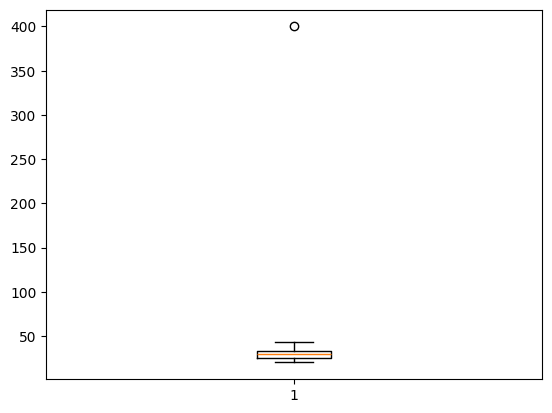

In [ ]:
plt.boxplot(lista_idades)

{'whiskers': [<matplotlib.lines.Line2D at 0x7a1d06c63d40>,
 'caps': [<matplotlib.lines.Line2D at 0x7a1d06e86a20>,
 'boxes': [<matplotlib.lines.Line2D at 0x7a1d06cb1430>],
 'medians': [<matplotlib.lines.Line2D at 0x7a1d06e86c90>],
 'fliers': [<matplotlib.lines.Line2D at 0x7a1d06e84e60>],
 'means': []}

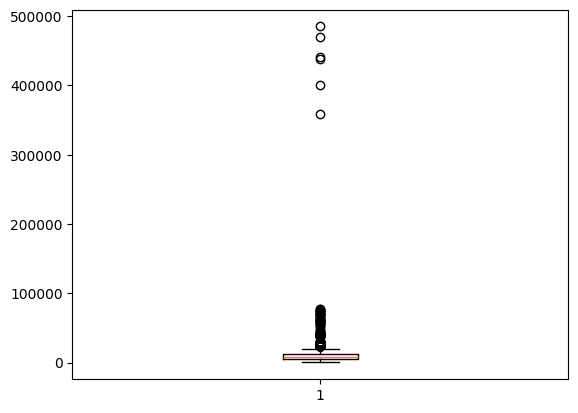

In [ ]:
plt.boxplot(dados['SALARIO'])

In [ ]:
Q1 = dados['SALARIO'].quantile(0.25)
Q1

np.float64(4751.5)

In [ ]:
Q3 = dados['SALARIO'].quantile(0.75)
Q3

np.float64(11794.5)

In [ ]:
IQR = Q3 - Q1
IQR

np.float64(7043.0)

In [ ]:
lim_superior = Q3 + (1.5*IQR)
lim_superior

np.float64(22359.0)

In [ ]:
lim_inferior = Q1 - (1.5*IQR)
lim_inferior

np.float64(-5813.0)

In [ ]:
dados['FAIXA SALARIAL'].value_counts()

,count
FAIXA SALARIAL,
de R$ 8.001/mês a R$ 12.000/mês,752
de R$ 4.001/mês a R$ 6.000/mês,584
de R$ 6.001/mês a R$ 8.000/mês,527
de R$ 12.001/mês a R$ 16.000/mês,437
de R$ 3.001/mês a R$ 4.000/mês,303
de R$ 2.001/mês a R$ 3.000/mês,285
de R$ 16.001/mês a R$ 20.000/mês,229
de R$ 1.001/mês a R$ 2.000/mês,216
de R$ 20.001/mês a R$ 25.000/mês,134


In [ ]:
media_salario = dados['SALARIO'].mean()
media_salario

np.float64(10517.53348162023)

In [ ]:
desvio_salario = dados['SALARIO'].std()
desvio_salario

18096.210989118474

In [ ]:
limite_superior = media_salario + (3*desvio_salario)
limite_superior

np.float64(64806.16644897565)

In [ ]:
dados[dados['SALARIO'] > limite_superior]['FAIXA SALARIAL'].value_counts()

,count
FAIXA SALARIAL,
Acima de R$ 40.001/mês,19
de R$ 30.001/mês a R$ 40.000/mês,3


In [ ]:
media_30_40 = dados[(dados['FAIXA SALARIAL'] == 'de R$ 30.001/mês a R$ 40.000/mês') & (dados['SALARIO'] < limite_superior)]['SALARIO'].mean()
media_30_40

np.float64(39002.19402985075)

In [ ]:
dados.loc[(dados['FAIXA SALARIAL'] == 'de R$ 30.001/mês a R$ 40.000/mês') & (dados['SALARIO'] > limite_superior), 'SALARIO']

,SALARIO
2053,470454.0
2257,358966.0
3201,441190.0


In [ ]:
dados.loc[(dados['FAIXA SALARIAL'] == 'de R$ 30.001/mês a R$ 40.000/mês') & (dados['SALARIO'] > limite_superior), 'SALARIO'] = media_30_40

In [ ]:
dados[dados['SALARIO'] > limite_superior]['FAIXA SALARIAL'].value_counts()

,count
FAIXA SALARIAL,
Acima de R$ 40.001/mês,19


In [ ]:
media_40 = dados[(dados['FAIXA SALARIAL'] == 'Acima de R$ 40.001/mês') & (dados['SALARIO'] < limite_superior)]['SALARIO'].mean()
media_40

np.float64(53127.846153846156)

In [ ]:
dados.loc[(dados['FAIXA SALARIAL'] == 'Acima de R$ 40.001/mês') & (dados['SALARIO'] > limite_superior), 'SALARIO'] = media_40

In [ ]:
dados[dados['SALARIO'] > limite_superior]['FAIXA SALARIAL'].value_counts()

,count
FAIXA SALARIAL,


{'whiskers': [<matplotlib.lines.Line2D at 0x7a1d045b0650>,
 'caps': [<matplotlib.lines.Line2D at 0x7a1d045b0bf0>,
 'boxes': [<matplotlib.lines.Line2D at 0x7a1d045b0410>],
 'medians': [<matplotlib.lines.Line2D at 0x7a1d045b1220>],
 'fliers': [<matplotlib.lines.Line2D at 0x7a1d045b14c0>],
 'means': []}

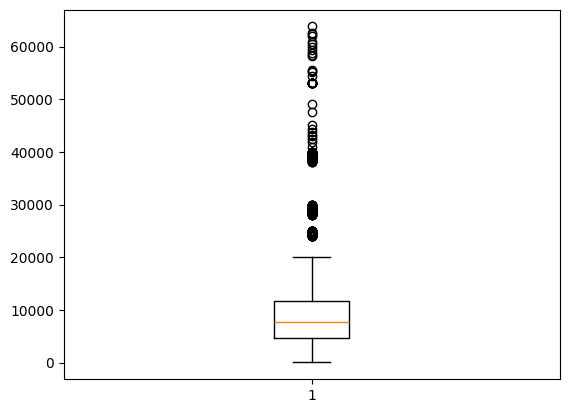

In [ ]:
plt.boxplot(dados['SALARIO'])

### Distribuição amostral e intervalo de confiança

In [ ]:
salarios = dados['SALARIO']

In [ ]:
salarios

,SALARIO
0,11194.0
1,4695.0
2,14202.0
3,15463.0
4,7733.0
...,...
4266,4329.0
4267,3758.0
4268,19607.0
4269,989.0


In [ ]:
media_amostral = np.mean(salarios)
media_amostral

np.float64(9904.390109813306)

In [ ]:
desvio_amostral = np.std(salarios)
desvio_amostral

8306.104872579343

In [ ]:
nivel_confianca = 0.95

In [ ]:
tamanho_amostra = len(salarios)
tamanho_amostra

4271

In [ ]:
from scipy import stats

In [ ]:
erro_padrao = stats.sem(salarios)
erro_padrao

np.float64(127.11109872023638)

In [ ]:
intervalo_confianca = stats.t.interval(nivel_confianca, tamanho_amostra-1, loc=media_amostral, scale=erro_padrao)
intervalo_confianca

(np.float64(9655.186295869078), np.float64(10153.593923757535))

## Featuring engineering

In [ ]:
def preencher_nivel(gestor, nivel):
  if gestor==1:
    return "Pessoa Gestora"
  else:
    return nivel

In [ ]:
dados['NOVO_NIVEL'] = dados.apply(lambda x: preencher_nivel(x['GESTOR?'], x['NIVEL']), axis=1)

In [ ]:
dados['NOVO_NIVEL'].value_counts()

,count
NOVO_NIVEL,
Pleno,1060
Júnior,1023
Sênior,898
Pessoa Gestora,713


In [ ]:
dados['NIVEL']

,NIVEL
0,Júnior
1,NaN
2,Pleno
3,Sênior
4,Pleno
...,...
4266,Pleno
4267,Pleno
4268,NaN
4269,Júnior


In [ ]:
dados = pd.get_dummies(dados, columns=['NIVEL'])

In [ ]:
dados.columns

Index(['Unnamed: 0', 'ID', 'IDADE', 'FAIXA IDADE', 'GENERO', 'COR/RACA/ETNIA',
       'PCD', 'EXPERIENCIA_PROFISSIONAL_PREJUDICADA', 'ASPECTOS_PREJUDICADOS',
       'VIVE_NO_BRASIL', 'ESTADO ONDE MORA', 'UF ONDE MORA',
       'REGIAO ONDE MORA', 'MUDOU DE ESTADO?', 'REGIAO DE ORIGEM',
       'NIVEL DE ENSINO', 'ÁREA DE FORMAÇÃO',
       'QUAL SUA SITUAÇÃO ATUAL DE TRABALHO?', 'SETOR',
       'NUMERO DE FUNCIONARIOS', 'GESTOR?', 'CARGO COMO GESTOR', 'CARGO ATUAL',
       'FAIXA SALARIAL',
       'QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE DADOS VOCÊ TEM?',
       'QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE TI/ENGENHARIA DE SOFTWARE VOCÊ TEVE ANTES DE COMEÇAR A TRABALHAR NA ÁREA DE DADOS?',
       'SALARIO', 'NOVO_NIVEL', 'NIVEL_Júnior', 'NIVEL_Pleno', 'NIVEL_Sênior'],
      dtype='object')

In [ ]:
def determinar_geracao(idade):
  if 39 < idade <= 58:
    return "Geração X"
  elif 29 < idade <= 39:
    return "Millenium"
  elif 13 < idade <= 29:
    return "Geração Z"
  else:
    return "Outra geração"

In [ ]:
dados['GERACAO'] = dados['IDADE'].apply(determinar_geracao)

In [ ]:
dados['GERACAO'].value_counts()

,count
GERACAO,
Geração Z,1999
Millenium,1761
Geração X,511


In [ ]:
dados2 = pd.read_excel('/content/drive/MyDrive/Curso PrograMaria Dados/ Planilha_Aula_parte2.xlsx')

In [ ]:
dados2.head()

,ID,Quanto tempo de experiência na área de dados você tem?,Quanto tempo de experiência na área de TI/Engenharia de Software você teve antes de começar a trabalhar na área de dados?,Você está satisfeito na sua empresa atual?,Qual o principal motivo da sua insatisfação com a empresa atual?,Você participou de entrevistas de emprego nos últimos 6 meses?,Você pretende mudar de emprego nos próximos 6 meses?,Quais os principais critérios que você leva em consideração no momento de decidir onde trabalhar?,Atualmente qual a sua forma de trabalho?,Qual a forma de trabalho ideal para você?,Caso sua empresa decida pelo modelo 100% presencial qual será sua atitude?,Sua empresa passu por Layoff em 2022?,Atuacao,Quais das linguagens listadas abaixo você utiliza no trabalho?
0,zzqzz3l9ily8nuo2m7wyzzqzz3w48o96,de 1 a 2 anos,de 7 a 10 anos,True,NaN,Não participei de entrevistas de emprego/proce...,Não estou buscando e não pretendo mudar de emp...,Benefícios,Modelo 100% presencial,Modelo híbrido com dias fixos de trabalho pres...,Vou aceitar e retornar ao modelo 100% presencial,Não ocorreram layoffs/demissões em massa na em...,Engenharia de Dados,SQL
1,zzls2oftfn9law393oezzls2ofhvfpzd,de 3 a 4 anos,Menos de 1 ano,False,Falta de oportunidade de crescimento no empreg...,"Sim, fiz entrevistas mas não fui aprovado",Estou em busca de oportunidades dentro ou fora...,"Remuneração/Salário, Plano de carreira e oport...",Modelo 100% presencial,Modelo híbrido flexível (o funcionário tem lib...,Vou aceitar e retornar ao modelo 100% presencial,Não ocorreram layoffs/demissões em massa na em...,Gestor,NaN
2,zzdwqzfqqp1ypc7ps6m0hzzdwqz292yi,de 3 a 4 anos,Mais de 10 anos,False,Falta de oportunidade de crescimento no empreg...,Não participei de entrevistas de emprego/proce...,"Não estou buscando, mas me considero aberto a ...","Remuneração/Salário, Flexibilidade de trabalho...",Modelo híbrido com dias fixos de trabalho pres...,Modelo híbrido flexível (o funcionário tem lib...,Vou procurar outra oportunidade no modelo híbr...,Não ocorreram layoffs/demissões em massa na em...,desenvolve modelos preditivos e algoritmos de...,1
3,zzbqh3uy7yk7k9qmkzzbqtb4s9faqspl,de 4 a 6 anos,Não tive experiência na área de TI/Engenharia ...,True,NaN,"Sim, fui aprovado e mudei de emprego","Não estou buscando, mas me considero aberto a ...","Remuneração/Salário, Flexibilidade de trabalho...",Modelo híbrido flexível (o funcionário tem lib...,Modelo híbrido flexível (o funcionário tem lib...,Vou procurar outra oportunidade no modelo híbr...,Não ocorreram layoffs/demissões em massa na em...,desenvolve modelos preditivos e algoritmos de...,0
4,zzaf1m95yan929rb94wzzaf1mekhvhpg,Não tenho experiência na área de dados,Mais de 10 anos,False,Falta de oportunidade de crescimento no empreg...,Não participei de entrevistas de emprego/proce...,"Não estou buscando, mas me considero aberto a ...","Remuneração/Salário, Oportunidade de aprendiza...",Modelo 100% presencial,Modelo 100% presencial,Vou aceitar e retornar ao modelo 100% presencial,Não ocorreram layoffs/demissões em massa na em...,Outra atuação,SQL


In [ ]:
dados = dados.merge(dados2, on='ID', how='left')
dados

,Unnamed: 0,ID,IDADE,FAIXA IDADE,GENERO,COR/RACA/ETNIA,PCD,EXPERIENCIA_PROFISSIONAL_PREJUDICADA,ASPECTOS_PREJUDICADOS,VIVE_NO_BRASIL,...,Qual o principal motivo da sua insatisfação com a empresa atual?,Você participou de entrevistas de emprego nos últimos 6 meses?,Você pretende mudar de emprego nos próximos 6 meses?,Quais os principais critérios que você leva em consideração no momento de decidir onde trabalhar?,Atualmente qual a sua forma de trabalho?,Qual a forma de trabalho ideal para você?,Caso sua empresa decida pelo modelo 100% presencial qual será sua atitude?,Sua empresa passu por Layoff em 2022?,Atuacao,Quais das linguagens listadas abaixo você utiliza no trabalho?
0,0,zzqzz3l9ily8nuo2m7wyzzqzz3w48o96,39.000000,35-39,Masculino,Parda,Não,Não acredito que minha experiência profissiona...,NaN,True,...,NaN,Não participei de entrevistas de emprego/proce...,Não estou buscando e não pretendo mudar de emp...,Benefícios,Modelo 100% presencial,Modelo híbrido com dias fixos de trabalho pres...,Vou aceitar e retornar ao modelo 100% presencial,Não ocorreram layoffs/demissões em massa na em...,Engenharia de Dados,SQL
1,1,zzls2oftfn9law393oezzls2ofhvfpzd,32.000000,30-34,Masculino,Parda,Não,"Sim, acredito que a minha a experiência profis...",Aprovação em processos seletivos/entrevistas,True,...,Falta de oportunidade de crescimento no empreg...,"Sim, fiz entrevistas mas não fui aprovado",Estou em busca de oportunidades dentro ou fora...,"Remuneração/Salário, Plano de carreira e oport...",Modelo 100% presencial,Modelo híbrido flexível (o funcionário tem lib...,Vou aceitar e retornar ao modelo 100% presencial,Não ocorreram layoffs/demissões em massa na em...,Gestor,NaN
2,2,zzdwqzfqqp1ypc7ps6m0hzzdwqz292yi,53.000000,50-54,Masculino,Branca,Não,NaN,NaN,True,...,Falta de oportunidade de crescimento no empreg...,Não participei de entrevistas de emprego/proce...,"Não estou buscando, mas me considero aberto a ...","Remuneração/Salário, Flexibilidade de trabalho...",Modelo híbrido com dias fixos de trabalho pres...,Modelo híbrido flexível (o funcionário tem lib...,Vou procurar outra oportunidade no modelo híbr...,Não ocorreram layoffs/demissões em massa na em...,desenvolve modelos preditivos e algoritmos de...,1
3,3,zzbqh3uy7yk7k9qmkzzbqtb4s9faqspl,27.000000,25-29,Masculino,Branca,Não,NaN,NaN,True,...,NaN,"Sim, fui aprovado e mudei de emprego","Não estou buscando, mas me considero aberto a ...","Remuneração/Salário, Flexibilidade de trabalho...",Modelo híbrido flexível (o funcionário tem lib...,Modelo híbrido flexível (o funcionário tem lib...,Vou procurar outra oportunidade no modelo híbr...,Não ocorreram layoffs/demissões em massa na em...,desenvolve modelos preditivos e algoritmos de...,0
4,4,zzaf1m95yan929rb94wzzaf1mekhvhpg,46.000000,45-49,Feminino,Branca,Não,Não acredito que minha experiência profissiona...,NaN,True,...,Falta de oportunidade de crescimento no empreg...,Não participei de entrevistas de emprego/proce...,"Não estou buscando, mas me considero aberto a ...","Remuneração/Salário, Oportunidade de aprendiza...",Modelo 100% presencial,Modelo 100% presencial,Vou aceitar e retornar ao modelo 100% presencial,Não ocorreram layoffs/demissões em massa na em...,Outra atuação,SQL
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4268,4266,01jnrn9f6va0menfhk2ztm01jnrn96bp,26.000000,25-29,Masculino,Branca,Não,NaN,NaN,True,...,NaN,"Sim, fui aprovado e mudei de emprego",Não estou buscando e não pretendo mudar de emp...,"Remuneração/Salário, Benefícios, Flexibilidade...",Modelo 100% remoto,Modelo híbrido flexível (o funcionário tem lib...,Vou procurar outra oportunidade no modelo híbr...,Não ocorreram layoffs/demissões em massa na em...,Análise de Dados,SQL
4269,4267,01dyfxam4u4bi29fem01dyfxaq9akvqp,30.000000,30-34,Feminino,Branca,Não,Não acredito que minha experiência profissiona...,NaN,True,...,NaN,Não participei de entrevistas de emprego/proce...,Não estou buscando e não pretendo mudar de emp...,"Ambient

In [ ]:
dados.columns

Index(['Unnamed: 0', 'ID', 'IDADE', 'FAIXA IDADE', 'GENERO', 'COR/RACA/ETNIA',
       'PCD', 'EXPERIENCIA_PROFISSIONAL_PREJUDICADA', 'ASPECTOS_PREJUDICADOS',
       'VIVE_NO_BRASIL', 'ESTADO ONDE MORA', 'UF ONDE MORA',
       'REGIAO ONDE MORA', 'MUDOU DE ESTADO?', 'REGIAO DE ORIGEM',
       'NIVEL DE ENSINO', 'ÁREA DE FORMAÇÃO',
       'QUAL SUA SITUAÇÃO ATUAL DE TRABALHO?', 'SETOR',
       'NUMERO DE FUNCIONARIOS', 'GESTOR?', 'CARGO COMO GESTOR', 'CARGO ATUAL',
       'FAIXA SALARIAL',
       'QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE DADOS VOCÊ TEM?',
       'QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE TI/ENGENHARIA DE SOFTWARE VOCÊ TEVE ANTES DE COMEÇAR A TRABALHAR NA ÁREA DE DADOS?',
       'SALARIO', 'NOVO_NIVEL', 'NIVEL_Júnior', 'NIVEL_Pleno', 'NIVEL_Sênior',
       'GERACAO', 'Quanto tempo de experiência na área de dados você tem?',
       'Quanto tempo de experiência na área de TI/Engenharia de Software você teve antes de começar a trabalhar na área de dados?',
       'Você está satis

In [ ]:
dados['Você pretende mudar de emprego nos próximos 6 meses?'].value_counts()

,count
Você pretende mudar de emprego nos próximos 6 meses?,
"Não estou buscando, mas me considero aberto a outras oportunidades",1354
Estou em busca de oportunidades dentro ou fora do Brasil,1011
Não estou buscando e não pretendo mudar de emprego nos próximos 6 meses,978
"Estou em busca de oportunidades, mas apenas fora do Brasil",353


In [ ]:
dados['EM BUSCA'] = dados['Você pretende mudar de emprego nos próximos 6 meses?'].str.contains('em busca', case=False)

In [ ]:
dados['EM BUSCA'].value_counts()

,count
EM BUSCA,
False,2332
True,1364


In [ ]:
dados['ABERTO_OPORTUNIDADES'] = dados['Você pretende mudar de emprego nos próximos 6 meses?'].str.contains('aberto', case=False)

In [ ]:
dados['ABERTO_OPORTUNIDADES'].value_counts()

,count
ABERTO_OPORTUNIDADES,
False,2342
True,1354


## Correlação

In [ ]:
dados.columns

Index(['Unnamed: 0', 'ID', 'IDADE', 'FAIXA IDADE', 'GENERO', 'COR/RACA/ETNIA',
       'PCD', 'EXPERIENCIA_PROFISSIONAL_PREJUDICADA', 'ASPECTOS_PREJUDICADOS',
       'VIVE_NO_BRASIL', 'ESTADO ONDE MORA', 'UF ONDE MORA',
       'REGIAO ONDE MORA', 'MUDOU DE ESTADO?', 'REGIAO DE ORIGEM',
       'NIVEL DE ENSINO', 'ÁREA DE FORMAÇÃO',
       'QUAL SUA SITUAÇÃO ATUAL DE TRABALHO?', 'SETOR',
       'NUMERO DE FUNCIONARIOS', 'GESTOR?', 'CARGO COMO GESTOR', 'CARGO ATUAL',
       'FAIXA SALARIAL',
       'QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE DADOS VOCÊ TEM?',
       'QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE TI/ENGENHARIA DE SOFTWARE VOCÊ TEVE ANTES DE COMEÇAR A TRABALHAR NA ÁREA DE DADOS?',
       'SALARIO', 'NOVO_NIVEL', 'NIVEL_Júnior', 'NIVEL_Pleno', 'NIVEL_Sênior',
       'GERACAO', 'Quanto tempo de experiência na área de dados você tem?',
       'Quanto tempo de experiência na área de TI/Engenharia de Software você teve antes de começar a trabalhar na área de dados?',
       'Você está satis

In [ ]:
correlacao_continua = dados['IDADE'].corr(dados['SALARIO'])
correlacao_continua

np.float64(0.2902441968622099)

In [ ]:
def cramer_coeficiente(coluna1, coluna2):
   tabela_cruzada = np.array(pd.crosstab(coluna1, coluna2))
   chi2 = chi2_contingency(tabela_cruzada)[0]
   soma = np.sum(tabela_cruzada)
   mini = min(tabela_cruzada.shape)-1
   cramer = np.sqrt(chi2/(soma*mini))
   return cramer

In [ ]:
cramer_coeficiente(dados['COR/RACA/ETNIA'], dados['NIVEL DE ENSINO'])

np.float64(0.04499106580480143)

In [ ]:
tabela_cruzada = pd.crosstab(dados['COR/RACA/ETNIA'], dados['NIVEL DE ENSINO'])
tabela_cruzada

NIVEL DE ENSINO,Doutorado ou Phd,Estudante de Graduação,Graduação/Bacharelado,Mestrado,Não tenho graduação formal,Prefiro não informar,Pós-graduação
COR/RACA/ETNIA,,,,,,,
Amarela,7,15,50,14,2,0,40
Branca,127,365,999,355,65,8,827
Indígena,0,2,4,2,0,0,3
Outra,0,0,6,3,1,0,7
Parda,50,178,333,113,33,3,344
Prefiro não informar,1,2,14,1,0,1,7
Preta,6,51,104,33,9,0,88


In [ ]:
np.array(tabela_cruzada)

array([[  7,  15,  50,  14,   2,   0,  40],
       [127, 365, 999, 355,  65,   8, 827],
       [  0,   2,   4,   2,   0,   0,   3],
       [  0,   0,   6,   3,   1,   0,   7],
       [ 50, 178, 333, 113,  33,   3, 344],
       [  1,   2,  14,   1,   0,   1,   7],
       [  6,  51, 104,  33,   9,   0,  88]])

In [ ]:
dados.to_csv('/content/drive/MyDrive/Curso PrograMaria Dados/analise_dados.csv', index=False) # salvar planilha em formato csv

## Conectando SQL com Pandas

In [ ]:
conexao = sqlite3.connect('/content/drive/MyDrive/Curso PrograMaria Dados/status_brasil')

In [ ]:
query = "SELECT * FROM Municipios_Brasileiros WHERE Cidade='Itaquaquecetuba';"

In [ ]:
query

"SELECT * FROM Municipios_Brasileiros WHERE Cidade='Itaquaquecetuba';"

In [ ]:
pd.read_sql(query, con=conexao)

,Cidade,Estado,Regiao,municipio_ID
0,Itaquaquecetuba,SP,Sudeste,5043


In [ ]:
a = 'batata'

In [ ]:
print('eu gosto de {}'.format(a))

eu gosto de batata


In [ ]:
a = ['batata', 'tomate', 'alface']

In [ ]:
print('Eu gosto de {}, {} e {}.'.format(a[0], a[1], a[2]))

Eu gosto de batata, tomate e alface.


In [ ]:
print('Eu gosto de {}.'.format(', '.join(a)))

Eu gosto de batata, tomate, alface.


In [ ]:
dados = pd.read_csv("/content/drive/MyDrive/Curso PrograMaria Dados/analise_dados.csv")

In [ ]:
dados.columns

Index(['Unnamed: 0', 'ID', 'IDADE', 'FAIXA IDADE', 'GENERO', 'COR/RACA/ETNIA',
       'PCD', 'EXPERIENCIA_PROFISSIONAL_PREJUDICADA', 'ASPECTOS_PREJUDICADOS',
       'VIVE_NO_BRASIL', 'ESTADO ONDE MORA', 'UF ONDE MORA',
       'REGIAO ONDE MORA', 'MUDOU DE ESTADO?', 'REGIAO DE ORIGEM',
       'NIVEL DE ENSINO', 'ÁREA DE FORMAÇÃO',
       'QUAL SUA SITUAÇÃO ATUAL DE TRABALHO?', 'SETOR',
       'NUMERO DE FUNCIONARIOS', 'GESTOR?', 'CARGO COMO GESTOR', 'CARGO ATUAL',
       'FAIXA SALARIAL',
       'QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE DADOS VOCÊ TEM?',
       'QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE TI/ENGENHARIA DE SOFTWARE VOCÊ TEVE ANTES DE COMEÇAR A TRABALHAR NA ÁREA DE DADOS?',
       'SALARIO', 'NOVO_NIVEL', 'NIVEL_Júnior', 'NIVEL_Pleno', 'NIVEL_Sênior',
       'GERACAO', 'Quanto tempo de experiência na área de dados você tem?',
       'Quanto tempo de experiência na área de TI/Engenharia de Software você teve antes de começar a trabalhar na área de dados?',
       'Você está satis

In [ ]:
lista_estados = list(dados['UF ONDE MORA'].unique())

In [ ]:
query = '''SELECT Municipios_Brasileiros.Estado, AVG(Municipio_Status.renda) FROM Municipios_Brasileiros
        INNER JOIN Municipio_Status ON Municipios_Brasileiros.municipio_ID = Municipio_Status.municipio_ID
        WHERE Municipios_Brasileiros.Estado IN ({})
        GROUP BY Municipios_Brasileiros.Estado;'''.format(', '.join(['?' for _ in lista_estados]))

In [ ]:
print(query)

SELECT Municipios_Brasileiros.Estado, AVG(Municipio_Status.renda) FROM Municipios_Brasileiros 
        INNER JOIN Municipio_Status ON Municipios_Brasileiros.municipio_ID = Municipio_Status.municipio_ID
        WHERE Municipios_Brasileiros.Estado IN (?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?)
        GROUP BY Municipios_Brasileiros.Estado;


In [ ]:
estados_renda = pd.read_sql(query, con=conexao, params=lista_estados)

In [ ]:
dados.columns

Index(['Unnamed: 0', 'ID', 'IDADE', 'FAIXA IDADE', 'GENERO', 'COR/RACA/ETNIA',
       'PCD', 'EXPERIENCIA_PROFISSIONAL_PREJUDICADA', 'ASPECTOS_PREJUDICADOS',
       'VIVE_NO_BRASIL', 'ESTADO ONDE MORA', 'UF ONDE MORA',
       'REGIAO ONDE MORA', 'MUDOU DE ESTADO?', 'REGIAO DE ORIGEM',
       'NIVEL DE ENSINO', 'ÁREA DE FORMAÇÃO',
       'QUAL SUA SITUAÇÃO ATUAL DE TRABALHO?', 'SETOR',
       'NUMERO DE FUNCIONARIOS', 'GESTOR?', 'CARGO COMO GESTOR', 'CARGO ATUAL',
       'FAIXA SALARIAL',
       'QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE DADOS VOCÊ TEM?',
       'QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE TI/ENGENHARIA DE SOFTWARE VOCÊ TEVE ANTES DE COMEÇAR A TRABALHAR NA ÁREA DE DADOS?',
       'SALARIO', 'NOVO_NIVEL', 'NIVEL_Júnior', 'NIVEL_Pleno', 'NIVEL_Sênior',
       'GERACAO', 'Quanto tempo de experiência na área de dados você tem?',
       'Quanto tempo de experiência na área de TI/Engenharia de Software você teve antes de começar a trabalhar na área de dados?',
       'Você está satis

In [ ]:
dados.rename(columns={'ESTADO':'UF ONDE MORA'}, inplace=True)

In [ ]:
dados.columns

Index(['Unnamed: 0', 'ID', 'IDADE', 'FAIXA IDADE', 'GENERO', 'COR/RACA/ETNIA',
       'PCD', 'EXPERIENCIA_PROFISSIONAL_PREJUDICADA', 'ASPECTOS_PREJUDICADOS',
       'VIVE_NO_BRASIL', 'ESTADO ONDE MORA', 'UF ONDE MORA',
       'REGIAO ONDE MORA', 'MUDOU DE ESTADO?', 'REGIAO DE ORIGEM',
       'NIVEL DE ENSINO', 'ÁREA DE FORMAÇÃO',
       'QUAL SUA SITUAÇÃO ATUAL DE TRABALHO?', 'SETOR',
       'NUMERO DE FUNCIONARIOS', 'GESTOR?', 'CARGO COMO GESTOR', 'CARGO ATUAL',
       'FAIXA SALARIAL',
       'QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE DADOS VOCÊ TEM?',
       'QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE TI/ENGENHARIA DE SOFTWARE VOCÊ TEVE ANTES DE COMEÇAR A TRABALHAR NA ÁREA DE DADOS?',
       'SALARIO', 'NOVO_NIVEL', 'NIVEL_Júnior', 'NIVEL_Pleno', 'NIVEL_Sênior',
       'GERACAO', 'Quanto tempo de experiência na área de dados você tem?',
       'Quanto tempo de experiência na área de TI/Engenharia de Software você teve antes de começar a trabalhar na área de dados?',
       'Você está satis

In [ ]:
dados.rename(columns={'UF ONDE MORA':'Estado'}, inplace=True)

In [ ]:
dados.columns

Index(['Unnamed: 0', 'ID', 'IDADE', 'FAIXA IDADE', 'GENERO', 'COR/RACA/ETNIA',
       'PCD', 'EXPERIENCIA_PROFISSIONAL_PREJUDICADA', 'ASPECTOS_PREJUDICADOS',
       'VIVE_NO_BRASIL', 'ESTADO ONDE MORA', 'Estado', 'REGIAO ONDE MORA',
       'MUDOU DE ESTADO?', 'REGIAO DE ORIGEM', 'NIVEL DE ENSINO',
       'ÁREA DE FORMAÇÃO', 'QUAL SUA SITUAÇÃO ATUAL DE TRABALHO?', 'SETOR',
       'NUMERO DE FUNCIONARIOS', 'GESTOR?', 'CARGO COMO GESTOR', 'CARGO ATUAL',
       'FAIXA SALARIAL',
       'QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE DADOS VOCÊ TEM?',
       'QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE TI/ENGENHARIA DE SOFTWARE VOCÊ TEVE ANTES DE COMEÇAR A TRABALHAR NA ÁREA DE DADOS?',
       'SALARIO', 'NOVO_NIVEL', 'NIVEL_Júnior', 'NIVEL_Pleno', 'NIVEL_Sênior',
       'GERACAO', 'Quanto tempo de experiência na área de dados você tem?',
       'Quanto tempo de experiência na área de TI/Engenharia de Software você teve antes de começar a trabalhar na área de dados?',
       'Você está satisfeito na sua 

In [ ]:
dados.merge(estados_renda, on='Estado', how='left')

,Unnamed: 0,ID,IDADE,FAIXA IDADE,GENERO,COR/RACA/ETNIA,PCD,EXPERIENCIA_PROFISSIONAL_PREJUDICADA,ASPECTOS_PREJUDICADOS,VIVE_NO_BRASIL,...,Quais os principais critérios que você leva em consideração no momento de decidir onde trabalhar?,Atualmente qual a sua forma de trabalho?,Qual a forma de trabalho ideal para você?,Caso sua empresa decida pelo modelo 100% presencial qual será sua atitude?,Sua empresa passu por Layoff em 2022?,Atuacao,Quais das linguagens listadas abaixo você utiliza no trabalho?,EM BUSCA,ABERTO_OPORTUNIDADES,AVG(Municipio_Status.renda)
0,0,zzqzz3l9ily8nuo2m7wyzzqzz3w48o96,39.000000,35-39,Masculino,Parda,Não,Não acredito que minha experiência profissiona...,NaN,True,...,Benefícios,Modelo 100% presencial,Modelo híbrido com dias fixos de trabalho pres...,Vou aceitar e retornar ao modelo 100% presencial,Não ocorreram layoffs/demissões em massa na em...,Engenharia de Dados,SQL,False,False,0.863000
1,1,zzls2oftfn9law393oezzls2ofhvfpzd,32.000000,30-34,Masculino,Parda,Não,"Sim, acredito que a minha a experiência profis...",Aprovação em processos seletivos/entrevistas,True,...,"Remuneração/Salário, Plano de carreira e oport...",Modelo 100% presencial,Modelo híbrido flexível (o funcionário tem lib...,Vou aceitar e retornar ao modelo 100% presencial,Não ocorreram layoffs/demissões em massa na em...,Gestor,NaN,True,False,0.572357
2,2,zzdwqzfqqp1ypc7ps6m0hzzdwqz292yi,53.000000,50-54,Masculino,Branca,Não,NaN,NaN,True,...,"Remuneração/Salário, Flexibilidade de trabalho...",Modelo híbrido com dias fixos de trabalho pres...,Modelo híbrido flexível (o funcionário tem lib...,Vou procurar outra oportunidade no modelo híbr...,Não ocorreram layoffs/demissões em massa na em...,desenvolve modelos preditivos e algoritmos de...,1,False,True,0.863000
3,3,zzbqh3uy7yk7k9qmkzzbqtb4s9faqspl,27.000000,25-29,Masculino,Branca,Não,NaN,NaN,True,...,"Remuneração/Salário, Flexibilidade de trabalho...",Modelo híbrido flexível (o funcionário tem lib...,Modelo híbrido flexível (o funcionário tem lib...,Vou procurar outra oportunidade no modelo híbr...,Não ocorreram layoffs/demissões em massa na em...,desenvolve modelos preditivos e algoritmos de...,0,False,True,0.652008
4,4,zzaf1m95yan929rb94wzzaf1mekhvhpg,46.000000,45-49,Feminino,Branca,Não,Não acredito que minha experiência profissiona...,NaN,True,...,"Remuneração/Salário, Oportunidade de aprendiza...",Modelo 100% presencial,Modelo 100% presencial,Vou aceitar e retornar ao modelo 100% presencial,Não ocorreram layoffs/demissões em massa na em...,Outra atuação,SQL,False,True,0.572357
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4268,4266,01jnrn9f6va0menfhk2ztm01jnrn96bp,26.000000,25-29,Masculino,Branca,Não,NaN,NaN,True,...,"Remuneração/Salário, Benefícios, Flexibilidade...",Modelo 100% remoto,Modelo híbrido flexível (o funcionário tem lib...,Vou procurar outra oportunidade no modelo híbr...,Não ocorreram layoffs/demissões em massa na em...,Análise de Dados,SQL,False,False,0.716571
4269,4267,01dyfxam4u4bi29fem01dyfxaq9akvqp,30.000000,30-34,Feminino,Branca,Não,Não acredito que minha experiência profissiona...,NaN,True,...,"Ambiente e clima de trabalho, Plano de carreir...",Modelo 100% remoto,Modelo híbrido flexível (o funcionário tem lib...,Vou aceitar e retornar ao modelo 100% presencial,Não ocorreram layoffs/demissões em massa na em...,Engenharia de Dados,"SQL, Python",False,False,0.652008
4270,4268,00zw9ks9d40z4u00zz3d20iix65qpli3,29.000000,25-29,Masculino,Branca,Não,NaN,NaN,True,...,"Remuneração/Salário, Ambiente e clima de traba...",Modelo híbrido com dias fixos de trabalho pres...,Modelo híbrido flexível (o funcionário tem lib...,Vou procurar outra oportunidade no modelo híbr...,"Sim, ocorreram layoffs/demissões em massa na e...",Gestor,NaN,False,True,0.716571
4271,4269,00xu7yujd7s57emj00xu7y0c3njix3de,20.205479,17-21,Masculino,Branca,Não,NaN,NaN,True,...,Oportunidade de aprendizado e trabalhar com re...,Modelo 100% presencial,Modelo 100% presencial,Vou

In [ ]:
dados = dados.merge(estados_renda, on='Estado', how='left')

In [ ]:
dados.columns

Index(['Unnamed: 0', 'ID', 'IDADE', 'FAIXA IDADE', 'GENERO', 'COR/RACA/ETNIA',
       'PCD', 'EXPERIENCIA_PROFISSIONAL_PREJUDICADA', 'ASPECTOS_PREJUDICADOS',
       'VIVE_NO_BRASIL', 'ESTADO ONDE MORA', 'Estado', 'REGIAO ONDE MORA',
       'MUDOU DE ESTADO?', 'REGIAO DE ORIGEM', 'NIVEL DE ENSINO',
       'ÁREA DE FORMAÇÃO', 'QUAL SUA SITUAÇÃO ATUAL DE TRABALHO?', 'SETOR',
       'NUMERO DE FUNCIONARIOS', 'GESTOR?', 'CARGO COMO GESTOR', 'CARGO ATUAL',
       'FAIXA SALARIAL',
       'QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE DADOS VOCÊ TEM?',
       'QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE TI/ENGENHARIA DE SOFTWARE VOCÊ TEVE ANTES DE COMEÇAR A TRABALHAR NA ÁREA DE DADOS?',
       'SALARIO', 'NOVO_NIVEL', 'NIVEL_Júnior', 'NIVEL_Pleno', 'NIVEL_Sênior',
       'GERACAO', 'Quanto tempo de experiência na área de dados você tem?',
       'Quanto tempo de experiência na área de TI/Engenharia de Software você teve antes de começar a trabalhar na área de dados?',
       'Você está satisfeito na sua 

In [ ]:
correlacao_renda_salario = salarios.corr(dados['AVG(Municipio_Status.renda)'])
correlacao_renda_salario

np.float64(0.035446425780982616)

## Visualização de dados

In [ ]:
dados = pd.read_csv("/content/drive/MyDrive/Curso PrograMaria Dados/analise_dados.csv")

In [ ]:
dados.head()

,Unnamed: 0,ID,IDADE,FAIXA IDADE,GENERO,COR/RACA/ETNIA,PCD,EXPERIENCIA_PROFISSIONAL_PREJUDICADA,ASPECTOS_PREJUDICADOS,VIVE_NO_BRASIL,...,Você pretende mudar de emprego nos próximos 6 meses?,Quais os principais critérios que você leva em consideração no momento de decidir onde trabalhar?,Atualmente qual a sua forma de trabalho?,Qual a forma de trabalho ideal para você?,Caso sua empresa decida pelo modelo 100% presencial qual será sua atitude?,Sua empresa passu por Layoff em 2022?,Atuacao,Quais das linguagens listadas abaixo você utiliza no trabalho?,EM BUSCA,ABERTO_OPORTUNIDADES
0,0,zzqzz3l9ily8nuo2m7wyzzqzz3w48o96,39.0,35-39,Masculino,Parda,Não,Não acredito que minha experiência profissiona...,NaN,True,...,Não estou buscando e não pretendo mudar de emp...,Benefícios,Modelo 100% presencial,Modelo híbrido com dias fixos de trabalho pres...,Vou aceitar e retornar ao modelo 100% presencial,Não ocorreram layoffs/demissões em massa na em...,Engenharia de Dados,SQL,False,False
1,1,zzls2oftfn9law393oezzls2ofhvfpzd,32.0,30-34,Masculino,Parda,Não,"Sim, acredito que a minha a experiência profis...",Aprovação em processos seletivos/entrevistas,True,...,Estou em busca de oportunidades dentro ou fora...,"Remuneração/Salário, Plano de carreira e oport...",Modelo 100% presencial,Modelo híbrido flexível (o funcionário tem lib...,Vou aceitar e retornar ao modelo 100% presencial,Não ocorreram layoffs/demissões em massa na em...,Gestor,NaN,True,False
2,2,zzdwqzfqqp1ypc7ps6m0hzzdwqz292yi,53.0,50-54,Masculino,Branca,Não,NaN,NaN,True,...,"Não estou buscando, mas me considero aberto a ...","Remuneração/Salário, Flexibilidade de trabalho...",Modelo híbrido com dias fixos de trabalho pres...,Modelo híbrido flexível (o funcionário tem lib...,Vou procurar outra oportunidade no modelo híbr...,Não ocorreram layoffs/demissões em massa na em...,desenvolve modelos preditivos e algoritmos de...,1,False,True
3,3,zzbqh3uy7yk7k9qmkzzbqtb4s9faqspl,27.0,25-29,Masculino,Branca,Não,NaN,NaN,True,...,"Não estou buscando, mas me considero aberto a ...","Remuneração/Salário, Flexibilidade de trabalho...",Modelo híbrido flexível (o funcionário tem lib...,Modelo híbrido flexível (o funcionário tem lib...,Vou procurar outra oportunidade no modelo híbr...,Não ocorreram layoffs/demissões em massa na em...,desenvolve modelos preditivos e algoritmos de...,0,False,True
4,4,zzaf1m95yan929rb94wzzaf1mekhvhpg,46.0,45-49,Feminino,Branca,Não,Não acredito que minha experiência profissiona...,NaN,True,...,"Não estou buscando, mas me considero aberto a ...","Remuneração/Salário, Oportunidade de aprendiza...",Modelo 100% presencial,Modelo 100% presencial,Vou aceitar e retornar ao modelo 100% presencial,Não ocorreram layoffs/demissões em massa na em...,Outra atuação,SQL,False,True


In [ ]:
genero_counts = dados['GENERO'].value_counts()

In [ ]:
import matplotlib.pyplot as plt

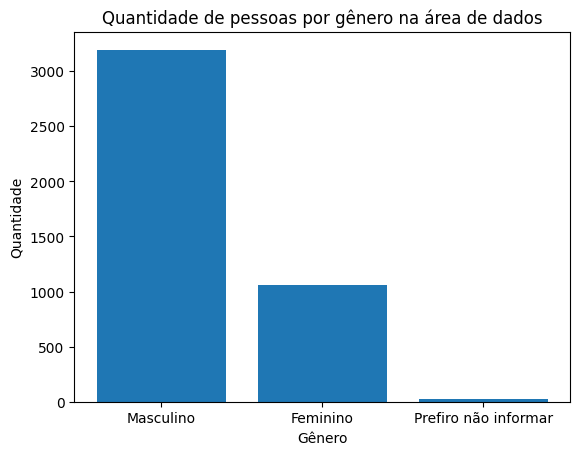

In [ ]:
plt.figure()
plt.bar(height = genero_counts.values, x = genero_counts.index)
plt.title('Quantidade de pessoas por gênero na área de dados')
plt.xlabel('Gênero')
plt.ylabel('Quantidade')
plt.show()

In [ ]:
import seaborn as sns

/tmp/ipykernel_37386/4188572074.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=dados, x='GENERO', palette='pastel')


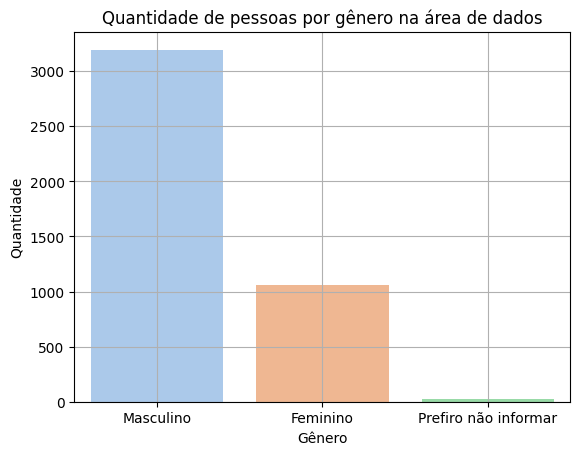

In [ ]:
plt.figure()
sns.countplot(data=dados, x='GENERO', palette='pastel')
plt.title('Quantidade de pessoas por gênero na área de dados')
plt.xlabel('Gênero')
plt.ylabel('Quantidade')
plt.grid(True)
plt.show()

/tmp/ipykernel_37386/3572233801.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


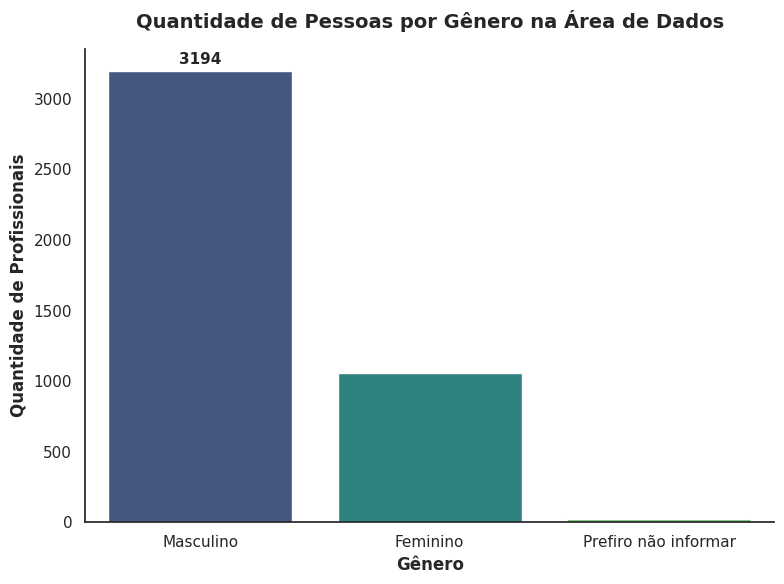

In [ ]:
# 1. Configura um estilo limpo e profissional do Seaborn
sns.set_theme(style="white")

# 2. Define o tamanho da imagem e a resolução (DPI) para melhor qualidade
plt.figure(figsize=(8, 6), dpi=100)

# 3. Cria o gráfico ordenando as barras para melhor leitura visual
ax = sns.countplot(
    data=dados,
    x='GENERO',
    palette='viridis',               # Paleta moderna com melhor contraste que a pastel
    order=dados['GENERO'].value_counts().index # Ordena da maior para a menor barra
)

# 4. Adiciona os números exatos em cima de cada barra (elimina a necessidade do grid)
ax.bar_label(ax.containers[0], fontsize=11, fontweight='bold', padding=3)

# 5. Customiza os textos para dar destaque profissional
plt.title('Quantidade de Pessoas por Gênero na Área de Dados', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Gênero', fontsize=12, fontweight='bold')
plt.ylabel('Quantidade de Profissionais', fontsize=12, fontweight='bold')

# 6. Remove as bordas desnecessárias (topo e direita) para limpar o visual
sns.despine()

# 7. Ajusta o espaçamento interno e exibe
plt.tight_layout()
plt.show()


In [ ]:
salario_por_idade = dados.groupby("IDADE")['SALARIO'].mean()
salario_por_idade

,SALARIO
IDADE,
18.000000,4230.307692
19.000000,4519.590909
20.000000,5004.272727
20.205479,3536.000000
21.000000,4578.737179
22.000000,4394.689815
23.000000,5602.406897
24.000000,6151.622449
25.000000,7616.392336


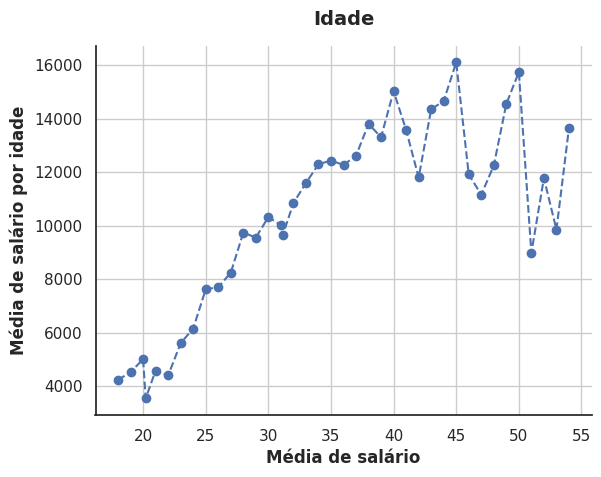

In [ ]:
plt.figure
plt.plot(salario_por_idade.index, salario_por_idade.values, marker='o', linestyle='--')
plt.title('Idade', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Média de salário', fontsize=12, fontweight='bold')
plt.ylabel('Média de salário por idade', fontsize=12, fontweight='bold')
sns.despine()
plt.grid(True)
plt.show()

In [ ]:
import plotly.express as px # gráfico interativo

In [ ]:
fig = px.line(salario_por_idade.reset_index(), x='IDADE', y='SALARIO', title='Média de salário por idade', markers=True)
fig.show()

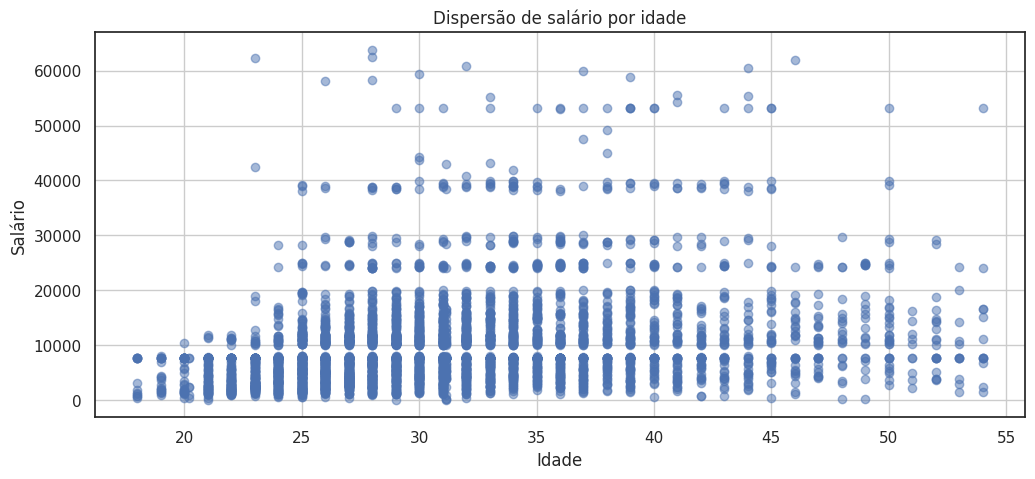

In [ ]:
plt.figure(figsize=(12,5))
plt.scatter(dados['IDADE'], dados['SALARIO'], alpha=0.5)
plt.xlabel('Idade')
plt.ylabel('Salário')
plt.title('Dispersão de salário por idade')
plt.grid(True)
plt.show() # não precisa estar aqui, sem ele já é executável

In [ ]:
fig = px.scatter(dados, x='IDADE', y='SALARIO', title='Dispersão de salário por idade')
fig.show()